## Mounting to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## Installing Needed Libraries

In [ ]:
# 1. Completely wipe the conflicting core libraries
!pip uninstall -y llama-index llama-index-core huggingface-hub requests rich

# 2. Install ONLY the essentials using the --no-deps strategy where needed
# to prevent "BigFrames" or "Gradio" from triggering a downgrade loop.
!pip install -q -U \
    llama-index-core \
    llama-index-llms-huggingface-api \
    llama-index-embeddings-huggingface \
    llama-index-readers-file \
    huggingface-hub \
    requests==2.32.4 \
    nest_asyncio

Found existing installation: llama-index-core 0.14.21
Uninstalling llama-index-core-0.14.21:
  Successfully uninstalled llama-index-core-0.14.21
Found existing installation: huggingface_hub 1.10.1
Uninstalling huggingface_hub-1.10.1:
  Successfully uninstalled huggingface_hub-1.10.1
Found existing installation: requests 2.32.4
Uninstalling requests-2.32.4:
  Successfully uninstalled requests-2.32.4
Found existing installation: rich 13.9.4
Uninstalling rich-13.9.4:
  Successfully uninstalled rich-13.9.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 24.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires rich<15.0.0,>=10.11.0, but you have rich 15.0.0 whi

## Testing on Simple RAG Pipeline

### Initial system architecture

In [ ]:
import os
import nest_asyncio
from google.colab import userdata

from llama_index.core import Settings, VectorStoreIndex, SimpleDirectoryReader
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

In [ ]:
# 1. Fix Colab loop
nest_asyncio.apply()

# 2. Setup Hugging Face Token
# (Make sure you have saved your 'HF_TOKEN' in Colab Secrets)
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# 3. Configure Settings - BOTH from Hugging Face
# LLM: Using Hugging Face's Serverless Inference API
Settings.llm = HuggingFaceInferenceAPI(
    model_name="Qwen/Qwen2.5-7B-Instruct",
    token=os.environ["HF_TOKEN"]
)

# EMBEDDING: Running locally (No API calls, no limits)
Settings.embed_model = HuggingFaceEmbedding(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# 4. Load & Index
DOCUMENT_PATH = "/content/drive/MyDrive/company_data"
documents = SimpleDirectoryReader(DOCUMENT_PATH).load_data()

index = VectorStoreIndex.from_documents(documents)
query_engine = index.as_query_engine(similarity_top_k=5)

# 5. Test Query
response = query_engine.query("What is the main topic of these documents?")
print("\n🤖 HUGGING FACE RAG RESPONSE:")
print(response)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🤖 HUGGING FACE RAG RESPONSE:
The main topic of these documents is Amazon's cybersecurity practices and policies, including the controls, technologies, methods, and systems designed to protect data and manage security risks.


### Testing #1

In [ ]:
# testing querying
response = query_engine.query("Can you summarize this annual report")
print(response)

This annual report for Amazon.com, Inc. covers the fiscal years 2022, 2023, and 2024. It includes financial statements such as the Consolidated Statements of Operations, Cash Flows, Comprehensive Income (Loss), Balance Sheets, and Stockholders' Equity. The report also details key financial metrics like net sales, operating income, and net income, showing significant growth from 2022 to 2024. Notable financial highlights include:

- Total net sales increased from $513,983 million in 2022 to $637,959 million in 2024.
- Operating income grew from $12,248 million in 2022 to $68,593 million in 2024.
- Net income also saw a substantial increase, from a loss of $2,722 million in 2022 to a profit of $59,248 million in 2024.

The report also includes information on stock-based compensation, restricted stock units, and income taxes. It notes that as of December 31, 2024, there


In [ ]:
# testing querying
response = query_engine.query("Does Amazon operate like startup? What does that mean")
print(response)

Amazon operates like a large startup in part because of its culture of prioritizing certain values and behaviors. This includes constantly choosing to prioritize customers, delivery, invention, ownership, speed, scrappiness, curiosity, and building a company that outlasts all its founders. This approach involves learning and iterating rapidly, even though not everything is always done perfectly. The company aims to maintain a startup mentality, focusing on innovation and customer-centricity, despite its size and established presence in the market.


In [ ]:
# testing querying
response = query_engine.query("What the vision that Amazon have for the future")
print(response)

## Adding the Source Citation and the Preventing Model from Hallucinating

In [ ]:
from llama_index.core import PromptTemplate

# Define a custom prompt that forces the AI to be honest
text_qa_template_str = (
    "Context information is below.\n"
    "---------------------\n"
    "{context_str}\n"
    "---------------------\n"
    "Given the context information and not prior knowledge, "
    "answer the query. If the answer is not contained within the context "
    "provided, please state that you do not have enough information to answer. "
    "Do not try to make up an answer.\n"
    "Query: {query_str}\n"
    "Answer: "
)

text_qa_template = PromptTemplate(text_qa_template_str)

In [ ]:
# Assuming you have already set up nest_asyncio and Settings...

# 1. Create the Query Engine with your custom prompt
query_engine = index.as_query_engine(
    text_qa_template=text_qa_template,
    similarity_top_k=5
)

# 2. Ask the question
user_question = "Can you explain the operating risks stated in the document"
response = query_engine.query(user_question)

# 3. Print the answer professionally
print("\n🤖 CHATBOT:")
print(response)

print("\n" + "-"*30)
print("📍 SOURCES & CITATIONS:")

# Loop through the sources used to generate this answer
for i, node in enumerate(response.source_nodes):
    # Extract metadata (LlamaIndex does this automatically from PyPDF)
    page_num = node.metadata.get('page_label', 'Unknown')
    file_name = node.metadata.get('file_name', 'Document')
    score = node.get_score() # How 'relevant' the math says this chunk is

    print(f"\n[{i+1}] Source: {file_name} (Page {page_num})")
    print(f"Similarity Score: {score:.4f}")
    print(f"Excerpt: \"{node.text[:150]}...\"")


🤖 CHATBOT:
The document outlines several operating risks that Amazon faces, including:

1. **Compliance Risks**: The company must build systems and adopt processes to properly comply with new reporting or collection obligations by the effective date. This can be challenging and may affect tax expense and liabilities due to various factors such as changes in business operations, acquisitions, investments, and intercompany transactions.

2. **Tax Risks**: Tax expense and liabilities are affected by numerous factors, including changes in business operations, acquisitions, investments, entry into new businesses and geographies, intercompany transactions, the relative amount of foreign earnings, losses in jurisdictions where tax benefits cannot be realized, the applicability of special or extraterritorial tax regimes, changes in foreign exchange rates, changes in stock price, changes to forecasts of income and loss, and changes in tax assets and liabilities. Significant judgment is require

## Testing on the Directory Containing Multiple Files

In [ ]:
DOCUMENT_PATH = "/content/drive/MyDrive/bible"

documents = SimpleDirectoryReader(DOCUMENT_PATH).load_data()
index = VectorStoreIndex.from_documents(documents)

query_engine = index.as_query_engine()
response = query_engine.query("How did God created the earth")
print(response, '\n')

# Loop through the sources used to generate this answer
for i, node in enumerate(response.source_nodes):
    # Extract metadata (LlamaIndex does this automatically from PyPDF)
    page_num = node.metadata.get('page_label', 'Unknown')
    file_name = node.metadata.get('file_name', 'Document')
    score = node.get_score() # How 'relevant' the math says this chunk is

    print(f"\n[{i+1}] Source: {file_name} (Page {page_num})")
    print(f"Similarity Score: {score:.4f}")
    print(f"Excerpt: \"{node.text[:150]}...\"")

In the beginning, God created the heavens and the earth. The earth was formless and empty, darkness covered the surface of the watery depths, and the Spirit of God was hovering over the surface of the waters. Then, God said, "Let there be light," and there was light. God saw that the light was good and separated the light from the darkness. God called the light "day," and the darkness he called "night." There was an evening, and there was a morning: one day. Then, God said, "Let there be an expanse between the waters, separating water from water." So, God made the expanse and separated the water under the expanse from the water above the expanse. And it was so. God called the expanse "sky." Evening came and then morning: the second day. Then, God said, "Let the water under the sky be gathered into one place, and let the dry land appear." And it was so. God called the dry land "earth," and the gathering of the water he called "seas." And God saw that it was good. 


[1] Source: book_gen

In [ ]:
response = query_engine.query("How did Jesus died? Did Jesus also ressurected?")
print(response, '\n')

# Loop through the sources used to generate this answer
for i, node in enumerate(response.source_nodes):
    # Extract metadata (LlamaIndex does this automatically from PyPDF)
    page_num = node.metadata.get('page_label', 'Unknown')
    file_name = node.metadata.get('file_name', 'Document')
    score = node.get_score() # How 'relevant' the math says this chunk is

    print(f"\n[{i+1}] Source: {file_name} (Page {page_num})")
    print(f"Similarity Score: {score:.4f}")
    print(f"Excerpt: \"{node.text[:150]}...\"")

According to the context provided, Jesus died on the cross as a result of crucifixion. He was buried by Joseph of Arimathea in a new tomb. The context also mentions that after the Sabbath, there was a violent earthquake, and an angel of the Lord descended from heaven to the tomb. The angel told the women that Jesus was not there because he had risen, just as he had said. This indicates that Jesus was resurrected from the dead. 


[1] Source: book_matthew.pdf (Page 31)
Similarity Score: 0.4954
Excerpt: "54   When  the cen tu ri on  and  those  with  him, 
 who  were keep ing  watch  over  Jesus,  saw  the 
earth quake  and  the  things  that  had hap ..."

[2] Source: book_matthew.pdf (Page 11)
Similarity Score: 0.4594
Excerpt: "12   A per son  is  worth  far  more  than  a  sheep;  so 
 it  is law ful  to  do  what  is  good  on  the Sab bath.”
13   Then  he  told  the  man, ..."


## Adding the Multimodal Part to the RAG System

Using the retriever and reranker from the Llama Nemotron

In [ ]:
# 1. Uninstall to clear the 'stuck' local state
!pip uninstall -y llama-index-embeddings-huggingface

# 2. Install the API-specific versions
!pip install -q -U \
    llama-index-core \
    llama-index-llms-huggingface-api \
    llama-index-embeddings-huggingface-api \
    nest_asyncio

Found existing installation: llama-index-embeddings-huggingface 0.7.0
Uninstalling llama-index-embeddings-huggingface-0.7.0:
  Successfully uninstalled llama-index-embeddings-huggingface-0.7.0


In [ ]:
# import os
# import nest_asyncio

# nest_asyncio.apply()

# from google.colab import userdata
# from llama_index.core import Settings, VectorStoreIndex, SimpleDirectoryReader
# from llama_index.core.postprocessor import LLMRerank
# from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
# from llama_index.embeddings.huggingface_api import HuggingFaceInferenceAPIEmbedding

# nest_asyncio.apply()

# os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# # 1. SEARCHER: Cloud-based Embedding (NO DOWNLOAD NEEDED)
# # This uses the HF API to embed your text, making it nearly instant.
# Settings.embed_model = HuggingFaceInferenceAPIEmbedding(
#     model_name="BAAI/bge-large-en-v1.5",
#     token=os.environ["HF_TOKEN"]
# )

# # 2. GENERATOR & RERANKER: Qwen-VL (Cloud-based)
# Settings.llm = HuggingFaceInferenceAPI(
#     model_name="Qwen/Qwen2.5-VL-7B-Instruct",
#     token=os.environ["HF_TOKEN"]
# )

# # 3. INITIALIZE RERANKER (Logic-based)
# reranker = LLMRerank(choice_batch_size=5, top_n=3)

# # 4. DATA & ENGINE
# # Note: Ensure your Drive is mounted before running this
# documents = SimpleDirectoryReader("/content/drive/MyDrive/data_testing_rag_capstone/windows_manual").load_data()
# index = VectorStoreIndex.from_documents(documents, show_progress=True)

# query_engine = index.as_query_engine(
#     similarity_top_k=10, .
#     node_postprocessors=[reranker]
# )

# print("🚀 RAG System Online and Ready!")

In [ ]:
# import os
# import nest_asyncio
# import asyncio
# import httpx
# from google.colab import userdata
# from llama_index.core import Settings, VectorStoreIndex, SimpleDirectoryReader
# from llama_index.core.postprocessor import LLMRerank
# from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
# from llama_index.embeddings.huggingface_api import HuggingFaceInferenceAPIEmbedding

# # 1. Force the loop to stay open
# nest_asyncio.apply()

# # Create a persistent client that won't close between batches
# persistent_client = httpx.AsyncClient(timeout=120.0)

# os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# # 2. SEARCHER: Pass the persistent client
# Settings.embed_model = HuggingFaceInferenceAPIEmbedding(
#     model_name="BAAI/bge-large-en-v1.5",
#     token=os.environ["HF_TOKEN"]
#     # We remove 'timeout' here and handle it via the client if needed
# )

# # 3. GENERATOR
# Settings.llm = HuggingFaceInferenceAPI(
#     model_name="Qwen/Qwen2.5-VL-7B-Instruct",
#     token=os.environ["HF_TOKEN"]
# )

# # 4. DATA & INDEXING
# # Using a very safe batch size of 5 to ensure we stay under the API rate limit
# documents = SimpleDirectoryReader("/content/drive/MyDrive/data_testing_rag_capstone/windows_manual").load_data()

# # We wrap the indexing in a try/except to prevent a crash from closing the session
# try:
#     index = VectorStoreIndex.from_documents(
#         documents,
#         show_progress=True,
#         insert_batch_size=5
#     )
# except RuntimeError as e:
#     if "Event loop is closed" in str(e):
#         print("⚠️ Loop attempted to close, but we are re-opening...")
#         loop = asyncio.new_event_loop()
#         asyncio.set_event_loop(loop)
#         index = VectorStoreIndex.from_documents(documents, show_progress=True, insert_batch_size=5)

# # 5. ENGINE
# reranker = LLMRerank(choice_batch_size=5, top_n=3)
# query_engine = index.as_query_engine(similarity_top_k=10, node_postprocessors=[reranker])

# print("🚀 RAG System Online and Stable!")

Generating response

In [ ]:
# from llama_index.core.schema import ImageDocument

# # 1. Load your UI screenshot
# # Replace with the actual path to your screenshot
# image_path = "/content/drive/MyDrive/data_testing_rag_capstone/windows_settings_ui_bigicon.png"
# image_doc = ImageDocument(image_path=image_path)

# # 2. Use the 'chat' or 'query' method with the image attached
# # If you are using the ChatEngine we built earlier:
# response = chat_engine.chat(
#     "I'm looking at this button in the UI. Can you find its function in the manual?",
#     image_docs=[image_doc]
# )

# print(f"\n🤖 ASSISTANT RESPONSE:\n{response}")

### Lets debug


In [ ]:
# import os
# import nest_asyncio
# from llama_index.core import Settings, VectorStoreIndex, SimpleDirectoryReader
# from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
# from llama_index.embeddings.huggingface_api import HuggingFaceInferenceAPIEmbedding

# nest_asyncio.apply()

# os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# # 1. SEARCHER: Disable 'Async' mode to stop the loop errors
# Settings.embed_model = HuggingFaceInferenceAPIEmbedding(
#     model_name="BAAI/bge-large-en-v1.5",
#     token=os.environ["HF_TOKEN"],
#     is_async=False # <--- THIS IS THE KEY FIX
# )

# # 2. GENERATOR
# Settings.llm = HuggingFaceInferenceAPI(
#     model_name="Qwen/Qwen2.5-VL-7B-Instruct",
#     token=os.environ["HF_TOKEN"],
#     is_async=False # <--- DISABLE ASYNC HERE TOO
# )

# # 3. DATA
# documents = SimpleDirectoryReader("/content/drive/MyDrive/data_testing_rag_capstone/windows_manual").load_data()

# # 4. INDEXING: Use a 'workers=1' to force sequential processing
# # This avoids the event loop completely.
# index = VectorStoreIndex.from_documents(
#     documents,
#     show_progress=True,
#     num_workers=1 # <--- FORCES ONE-BY-ONE PROCESSING
# )

# print("🚀 RAG System Online (Stable Synchronous Mode)")

### Using simplest multimodal RAG architecture

In [ ]:
!pip install -q -U llama-index-core llama-index-readers-file llama-index-llms-huggingface-api llama-index-embeddings-huggingface nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 11.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
import os
import nest_asyncio
from google.colab import userdata
from llama_index.core import Settings, VectorStoreIndex, SimpleDirectoryReader
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# 1. Essential Patch
nest_asyncio.apply()

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# 2. LOCAL EMBEDDER (Searcher)
# Running this locally prevents the "Event loop is closed" error during indexing
Settings.embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5"
)

# 3. CLOUD LLM (Generator)
# Qwen2.5-VL is the 'Brain' that will handle your text + image prompts
Settings.llm = HuggingFaceInferenceAPI(
    model_name="Qwen/Qwen2.5-VL-7B-Instruct",
    token=os.environ["HF_TOKEN"]
)

# 4. DATA LOADING
# This will load your PDFs and images from the folder
documents = SimpleDirectoryReader("/content/drive/MyDrive/data_testing_rag_capstone/windows_manual").load_data()

# 5. INDEXING
# Since we use a local embed_model, this should be 100% stable
index = VectorStoreIndex.from_documents(documents, show_progress=True)

# 6. ENGINE (Simple & Fast)
query_engine = index.as_query_engine(similarity_top_k=3)

print("🚀 Simple RAG System Online!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/327 [00:00<?, ?it/s]

🚀 Simple RAG System Online!


In [ ]:
# from llama_index.core.query_engine import SimpleMultiModalQueryEngine
# from llama_index.core.schema import ImageDocument

# # 1. Initialize the specialized engine (if not already done)
# mm_query_engine = SimpleMultiModalQueryEngine(
#     retriever=index.as_retriever(similarity_top_k=3),
#     multi_modal_llm=Settings.llm,
# )

# # 2. Path to your UI Screenshot
# image_path = "/content/drive/MyDrive/data_testing_rag_capstone/windows_settings_ui_bigicon.png"

# # 3. Use 'query_str' instead of 'prompt'
# # This is the standard argument name for this specific engine
# response = mm_query_engine.image_query(
#     image_path=image_path,
#     query_str="Identify the button in this screenshot and explain its function based on the manual."
# )

# print(f"\n🤖 QWEN RESPONSE:\n{response}")

In [ ]:
from llama_index.core.query_engine import SimpleMultiModalQueryEngine
from llama_index.core.schema import ImageDocument

# 1. Initialize the specialized engine (if not already done)
mm_query_engine = SimpleMultiModalQueryEngine(
    retriever=index.as_retriever(similarity_top_k=3),
    multi_modal_llm=Settings.llm,
)

# 2. Path to your UI Screenshot
image_path = "/content/drive/MyDrive/data_testing_rag_capstone/windows_settings_ui_bigicon.png"

# 3. Use 'query_str' instead of 'prompt'
# This is the standard argument name for this specific engine
response = mm_query_engine.image_query(
    prompt_str="Identify the button in this screenshot and explain its function based on the manual.",
    image_path=image_path,
)

print(f"\n🤖 QWEN RESPONSE:\n{response}")

AttributeError: 'VectorIndexRetriever' object has no attribute 'image_to_image_retrieve'

In [ ]:
# from llama_index.core.schema import ImageDocument, QueryBundle
# from llama_index.core.llms import ChatMessage, MessageRole
# import base64
# import os

# # 1. Path to your UI Screenshot
# image_path = "/content/drive/MyDrive/data_testing_rag_capstone/windows_settings_ui_bigicon.png"

# # 2. Base64 encode the image for the multimodal LLM (Qwen-VL)
# with open(image_path, "rb") as f:
#     image_bytes = f.read()
# image_base64 = base64.b64encode(image_bytes).decode("utf-8")
# image_url = f"data:image/png;base64,{image_base64}"

# # 3. Define the text query for the retriever
# text_query_str = "Identify the button in this screenshot and explain its function based on the manual."

# # 4. Use the text-based retriever to get relevant text nodes
# # This uses the 'index' created earlier with HuggingFaceEmbedding (text-only)
# retriever = index.as_retriever(similarity_top_k=3)
# retrieved_nodes = retriever.retrieve(QueryBundle(text_query_str))

# # 5. Extract context from retrieved nodes
# context_str = "\n\n".join([n.text for n in retrieved_nodes])

# # 6. Construct the multimodal prompt for the LLM (Settings.llm is Qwen-VL)
# messages = [
#     ChatMessage(
#         role=MessageRole.SYSTEM,
#         content="You are a helpful assistant. Use the provided context to answer the question. If the answer is not in the context, state that you do not have enough information.",
#     ),
#     ChatMessage(
#         role=MessageRole.USER,
#         content=f"Context information is below.\n---------------------\n{context_str}\n---------------------\nQuery: {text_query_str}",
#         image_url=image_url # Pass the image directly to the LLM
#     )
# ]

# # 7. Get response from the multimodal LLM (Settings.llm)
# response = Settings.llm.chat(messages)

# # print(f"\n🤖 QWEN RESPONSE:\n{response.message.content}")
# print(f"\n🤖 QWEN RESPONSE:\n{response.message.content}")

# # Optionally, print sources
# print("\n" + "-"*30)
# print("📍 SOURCES & CITATIONS:")
# for i, node in enumerate(retrieved_nodes):
#     page_num = node.metadata.get('page_label', 'Unknown')
#     file_name = node.metadata.get('file_name', 'Document')
#     score = node.get_score()
#     print(f"\n[{i+1}] Source: {file_name} (Page {page_num})")
#     print(f"Similarity Score: {score:.4f}")
#     print(f"Excerpt: \"{node.text[:150]}...\"")

### Using LlamaParse to do parsing from the pdf and separate the vector database for the image and text

In [ ]:
!pip install -q -U llama-parse llama-index-core

In [ ]:
import os
import glob
import nest_asyncio
from google.colab import userdata
from llama_parse import LlamaParse

# 1. APPLY PATCH FIRST
nest_asyncio.apply()

os.environ["LLAMAPARSE_API"] = userdata.get('LLAMAPARSE_API')

# 2. Initialize the Parser
parser = LlamaParse(
    api_key=os.environ["LLAMAPARSE_API"],
    result_type="markdown",
    extract_charts=True
)

# 3. MANUAL DIRECTORY READING
# We bypass SimpleDirectoryReader to strictly control the event loop
directory_path = "/content/drive/MyDrive/data_testing_rag_capstone/windows_manual/"
pdf_files = glob.glob(os.path.join(directory_path, "*.pdf"))

all_documents = []

print(f"📁 Found {len(pdf_files)} PDF files. Starting extraction...")

# 4. PARSE ONE BY ONE
for pdf_path in pdf_files:
    file_name = os.path.basename(pdf_path)
    print(f"⏳ Uploading and parsing: {file_name}...")

    try:
        # parser.load_data() is much safer than routing through a reader
        docs = parser.load_data(pdf_path)
        all_documents.extend(docs)
        print(f"   ✅ Success! Extracted {len(docs)} markdown pages.")
    except Exception as e:
        print(f"   ❌ Failed to parse {file_name}. Error: {e}")

print(f"\n🎉 Total Multimodal Chunks Ready for Indexing: {len(all_documents)}")

/tmp/ipykernel_26458/329284597.py:5: DeprecationWarning: The 'llama-parse' package is deprecated and will no longer receive updates. Please migrate to the new unified SDK. See https://developers.llamaindex.ai/python/cloud/llamaparse/getting_started/ and https://github.com/run-llama/llama-cloud-py/blob/main/README.md for migration instructions.
  from llama_parse import LlamaParse


📁 Found 2 PDF files. Starting extraction...
⏳ Uploading and parsing: Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf...
Started parsing the file under job_id 6c236c35-59b6-4150-9646-73f07881b04e
   ✅ Success! Extracted 201 markdown pages.
⏳ Uploading and parsing: windows_manual_userguide.pdf...
Error while parsing the file '/content/drive/MyDrive/data_testing_rag_capstone/windows_manual/windows_manual_userguide.pdf': Event loop is closed
   ✅ Success! Extracted 0 markdown pages.

🎉 Total Multimodal Chunks Ready for Indexing: 201


## Lets start over again - MultiModal RAG

In [ ]:
!pip install -q -U \
    llama-index-core \
    pymupdf \
    llama-index-embeddings-huggingface \
    llama-index-embeddings-clip \
    llama-index-multi-modal-llms-gemini \
    nest_asyncio \
    git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
import os
import fitz # PyMuPDF for local extraction
import nest_asyncio
from google.colab import userdata

# LlamaIndex Core
from llama_index.core import Settings, Document
from llama_index.core.schema import ImageDocument
from llama_index.core.indices import MultiModalVectorStoreIndex

# The 3 Native Models (No custom classes needed!)
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.embeddings.clip import ClipEmbedding
# from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.multi_modal_llms.gemini import GeminiMultiModal

# --- DIRECTORY SETUP ---
# Update these paths if your folders are named differently!
BASE_DIR = "/content/drive/MyDrive/data_testing_rag_capstone"
pdf_dir = os.path.join(BASE_DIR, "windows_manual")

# 🔥 THIS IS THE CRITICAL FIX: Saving images directly to Google Drive
image_save_dir = os.path.join(BASE_DIR, "capstone_extracted_images")
persist_dir = os.path.join(BASE_DIR, "capstone_saved_index")

os.makedirs(image_save_dir, exist_ok=True)
os.makedirs(persist_dir, exist_ok=True)

# Apply patch to prevent colab crashes
nest_asyncio.apply()
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

# --- 1. INITIALIZE MODELS (1 Line Each) ---
print("1. Loading Models...")

# 1. New Lightweight Text Searcher
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# 2. Image Embedding
image_embedder = ClipEmbedding(model_name="ViT-L/14", embed_batch_size=16)

# # Multimodal Brain (Qwen)
# Settings.llm = HuggingFaceInferenceAPI(
#     model_name="Qwen/Qwen2.5-VL-7B-Instruct",
#     token=os.environ["HF_TOKEN"]
# )

# Using the stable and free model
Settings.llm = GeminiMultiModal(model="gemini-2.5-flash-lite")

print("✅ Models initiated.")

1. Loading Models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/clip/clip.py:57: UserWarning: /root/.cache/clip/ViT-L-14.pt exists, but the SHA256 checksum does not match; re-downloading the file
  warnings.warn(f"{download_target} exists, but the SHA256 checksum does not match; re-downloading the file")
100%|███████████████████████████████████████| 890M/890M [00:12<00:00, 72.1MiB/s]
/tmp/ipykernel_983/2082957194.py:50: DeprecationWarning: Call to deprecated class GeminiMultiModal. (This package has been deprecated and will no longer be maintained. Please use llama-index-llms-google-genai instead. See Multi Modal LLMs documentation for a complete guide on migration: https://docs.llamaindex.ai/en/st

✅ Models initiated.


In [ ]:
# --- EXTRACT DATA ---
print("3. Extracting Text and Saving Images to Google Drive...")
documents = []

for file_name in os.listdir(pdf_dir):
    if file_name.endswith(".pdf"):
        pdf_path = os.path.join(pdf_dir, file_name)
        doc = fitz.open(pdf_path)

        for page_num in range(len(doc)):
            page = doc[page_num]

            # Extract Text
            text = page.get_text()
            if text.strip():
                documents.append(Document(text=text, metadata={"page": page_num, "source": file_name}))

            # Extract Images
            for img_index, img in enumerate(page.get_images(full=True)):
                base_image = doc.extract_image(img[0])

                # File name for the image
                img_filename = f"{file_name}_p{page_num}_i{img_index}.{base_image['ext']}"
                # Full path pointing to Google Drive
                img_filepath = os.path.join(image_save_dir, img_filename)

                # Save the image permanently to Drive
                with open(img_filepath, "wb") as f:
                    f.write(base_image["image"])

                # Tell LlamaIndex where the permanent image lives
                documents.append(ImageDocument(image_path=img_filepath, metadata={"page": page_num, "source": file_name}))

print(f"   ✅ Saved {len(documents)} total chunks to Drive.")

# --- BUILD & SAVE INDEX ---
print("4. Building the Vector Database (This may take a few minutes)...")
index = MultiModalVectorStoreIndex.from_documents(
    documents,
    image_embed_model=image_embedder,
    show_progress=True
)

print("5. Saving Database to Google Drive...")
index.storage_context.persist(persist_dir=persist_dir)

print("🚀 INGESTION COMPLETE! Your data is now permanently locked in Google Drive.")

3. Extracting Text and Saving Images to Google Drive...
   ✅ Saved 501 total chunks to Drive.
4. Building the Vector Database (This may take a few minutes)...


Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/325 [00:00<?, ?it/s]

Generating image embeddings:   0%|          | 0/184 [00:00<?, ?it/s]

5. Saving Database to Google Drive...
🚀 INGESTION COMPLETE! Your data is now permanently locked in Google Drive.


In [ ]:
# --- BUILD ENGINE ---
print("4. Creating Query Engine...")
query_engine = index.as_query_engine(
    llm=Settings.llm,
    similarity_top_k=3,
    image_similarity_top_k=2
)

print("🚀 CLEAN MULTIMODAL RAG ONLINE!")

4. Creating Query Engine...
🚀 CLEAN MULTIMODAL RAG ONLINE!


Testing the RAG System

In [ ]:
from llama_index.core.schema import ImageDocument

# 1. Path to your UI Screenshot
user_screenshot_path = "/content/drive/MyDrive/data_testing_rag_capstone/windows_settings_ui_bigicon.png"

print("🧠 Querying the Manual...")

# 2. Use 'image_query' and pass the path directly (no ImageDocument wrapper needed here!)
response = query_engine.image_query(
    image_path=user_screenshot_path,
    prompt_str="Look at this screenshot. Identify this UI element and explain what it does based on the manual."
)

print(f"\n🤖 QWEN RESPONSE:\n{response}")

# print("\n🔍 SOURCES USED BY THE SYSTEM:")
# for node in response.source_nodes:
#     print(f"- {str(node.node.get_content())[:150]}...")

print("\n🔍 SOURCES USED BY THE SYSTEM:")

for i, node_obj in enumerate(response.source_nodes):
    # node_obj is a 'NodeWithScore' object, so we extract the actual node
    node = node_obj.node

    # Extract the metadata (this is where page numbers and file paths live)
    metadata = node.metadata

    # Determine what type of node it is
    node_type = type(node).__name__

    print(f"\n[ Source {i+1} | Type: {node_type} ]")

    # Print the metadata so you know exactly where it came from
    if metadata:
        # Example output: {'page': 42, 'source': 'windows_manual.pdf'}
        print(f"📍 Location: {metadata}")

    # If it's text, print the snippet. If it's an image, print the path.
    if node_type == "TextNode":
        content = node.get_content().strip()
        print(f"📄 Text: {content[:200]}...\n")
    elif node_type == "ImageNode":
        # ImageNodes store their file path in the metadata or image_path attribute
        img_path = getattr(node, 'image_path', 'Path not found')
        print(f"🖼️ Image Path: {img_path}\n")

🧠 Querying the Manual...

🤖 QWEN RESPONSE:
The UI element is a search bar. It allows users to search for specific settings within the application.

🔍 SOURCES USED BY THE SYSTEM:

[ Source 1 | Type: ImageNode ]
📍 Location: {'page': 33, 'source': 'Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf'}
🖼️ Image Path: /content/drive/MyDrive/data_testing_rag_capstone/capstone_extracted_images/Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf_p33_i0.png


[ Source 2 | Type: ImageNode ]
📍 Location: {'page': 182, 'source': 'Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf'}
🖼️ Image Path: /content/drive/MyDrive/data_testing_rag_capstone/capstone_extracted_images/Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf_p182_i0.png



In [ ]:
# 1. Path to your UI Screenshot
user_screenshot_path = "/content/drive/MyDrive/data_testing_rag_capstone/windows_settings_ui_powernsleep.png"

print("🧠 Querying the Manual...")

# 2. Use 'image_query' and pass the path directly (no ImageDocument wrapper needed here!)
response = query_engine.image_query(
    image_path=user_screenshot_path,
    prompt_str="Look at this screenshot. Identify this UI element and explain what it does based on the manual."
)

print(f"\n🤖 QWEN RESPONSE:\n{response}")

print("\n🔍 SOURCES USED BY THE SYSTEM:")
for i, node_obj in enumerate(response.source_nodes):
    # node_obj is a 'NodeWithScore' object, so we extract the actual node
    node = node_obj.node

    # Extract the metadata (this is where page numbers and file paths live)
    metadata = node.metadata

    # Determine what type of node it is
    node_type = type(node).__name__

    print(f"\n[ Source {i+1} | Type: {node_type} ]")

    # Print the metadata so you know exactly where it came from
    if metadata:
        # Example output: {'page': 42, 'source': 'windows_manual.pdf'}
        print(f"📍 Location: {metadata}")

    # If it's text, print the snippet. If it's an image, print the path.
    if node_type == "TextNode":
        content = node.get_content().strip()
        print(f"📄 Text: {content[:200]}...\n")
    elif node_type == "ImageNode":
        # ImageNodes store their file path in the metadata or image_path attribute
        img_path = getattr(node, 'image_path', 'Path not found')
        print(f"🖼️ Image Path: {img_path}\n")

🧠 Querying the Manual...

🤖 QWEN RESPONSE:
The UI element is the "Power & sleep" settings page in Windows 10. It allows users to configure how long their screen stays on and how long their PC waits before going to sleep when plugged in. The "Related settings" section links to "Additional power settings," which opens the "Power Options" control panel. This control panel offers more advanced power management features, including the ability to choose between different power plans like "Balanced," "High performance," and "Power saver," each with its own performance and energy consumption characteristics.

🔍 SOURCES USED BY THE SYSTEM:

[ Source 1 | Type: ImageNode ]
📍 Location: {'page': 34}
🖼️ Image Path: /content/extracted_images/Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf_p34_i0.png


[ Source 2 | Type: ImageNode ]
📍 Location: {'page': 34}
🖼️ Image Path: /content/extracted_images/Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf_p34_i1.png



RAG can receive prompt with or without user inputting text

In [ ]:
# Simulate the user's input
user_text_prompt = "What are the steps to update Windows?"
user_uploaded_image = None # Imagine they didn't upload anything this time

print("🧠 Processing Query...")

# The "Smart Router"
if user_uploaded_image:
    # 1. IMAGE + TEXT MODE
    print("Detected Image. Running Multimodal Search...")
    response = query_engine.image_query(
        image_path=user_uploaded_image,
        query_str=user_text_prompt
    )
else:
    # 2. TEXT ONLY MODE
    print("No image detected. Running Text Search...")
    response = query_engine.query(user_text_prompt)

print(f"\n🤖 SYSTEM RESPONSE:\n{response}")

print("\n🔍 SOURCES USED:")
for i, node_obj in enumerate(response.source_nodes):
    node = node_obj.node
    node_type = type(node).__name__

    print(f"\n[ Source {i+1} | Type: {node_type} ]")
    if node_type == "TextNode":
        print(f"📄 Text: {node.get_content().strip()[:150]}...")
    elif node_type == "ImageNode":
        print(f"🖼️ Image Path: {getattr(node, 'image_path', 'Path not found')}")

🧠 Processing Query...
No image detected. Running Text Search...

🤖 SYSTEM RESPONSE:
Based on the provided context, here are the steps to update Windows:

1.  **Access the web from your Windows PC:** Windows will present an option to download the necessary files for an upgrade.
2.  **Use an ISO file:** If you have already downloaded the ISO and burned it onto a DVD, you can use that for the upgrade.

In both cases, a wizard will appear, allowing you to choose whether to keep or delete your data. Once you make your selection, the process will complete in a few minutes.

🔍 SOURCES USED:

[ Source 1 | Type: TextNode ]
📄 Text: CHAPTER 1  An overview of Windows 10	
3
Update, with additional reliability improvements, hardware driver updates, and the rare out-of-band 
security ...

[ Source 2 | Type: TextNode ]
📄 Text: Choosing to upgrade to Windows 10 is the easiest process. If you access the web
from your Windows PC, Windows will give you an option to download the
...

[ Source 3 | Type: Tex

🧠 Processing Query...
Detected Image. Running Multimodal Search...

🤖 SYSTEM RESPONSE:
To power off the computer, you can adjust the "Sleep" settings. In the provided screenshot, under the "Sleep" section, you can set how long the PC goes to sleep after being plugged in. By setting this to a shorter duration, the computer will enter sleep mode more quickly, which is a step towards powering it off.

Additionally, the "Power Options" window, accessible through "Additional power settings" in the first screenshot, allows for more granular control over power management. While it doesn't directly offer a "power off" setting, it lets you customize power plans, which can influence how quickly your computer goes to sleep or shuts down.

🔍 SOURCES USED:

🔍 SOURCES USED BY THE SYSTEM:

----------------------------------------
[ Source 1 | Type: ImageNode ]
📍 Location: {'page': 34}
🖼️ Image Path: /content/extracted_images/Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf_p34_i0.png
👇 Retrieved 

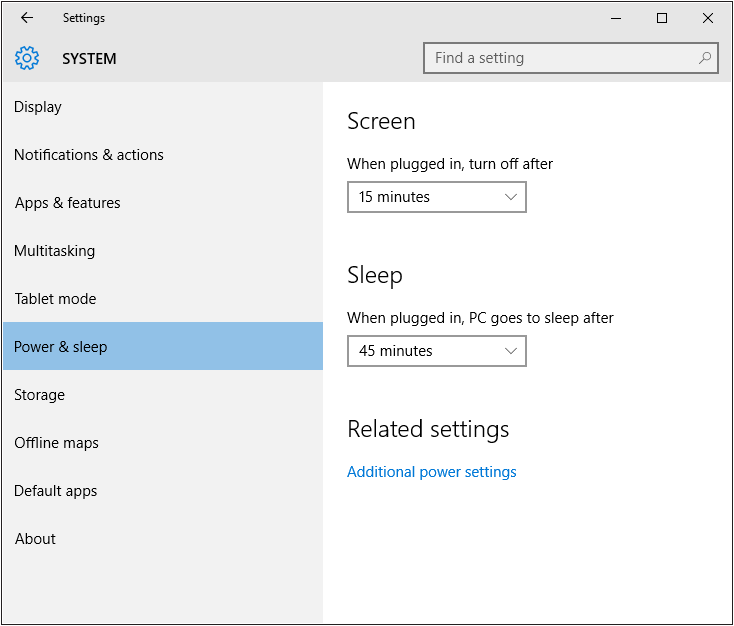


----------------------------------------
[ Source 2 | Type: ImageNode ]
📍 Location: {'page': 34}
🖼️ Image Path: /content/extracted_images/Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf_p34_i1.png
👇 Retrieved Visual Context:


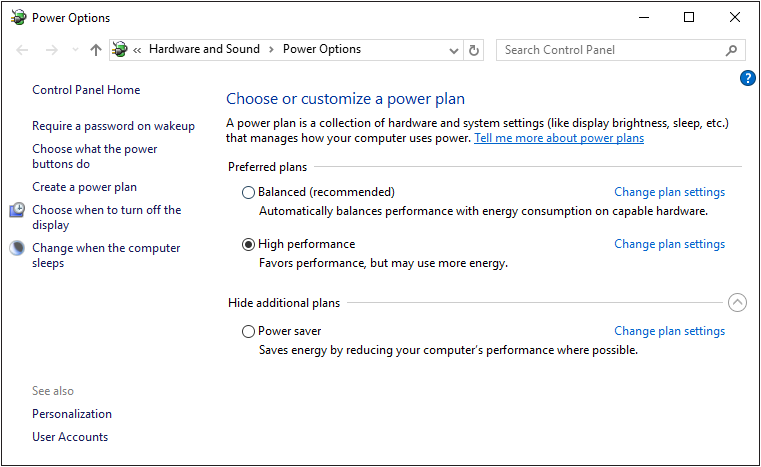

In [ ]:
# Simulate the user's input
user_text_prompt = "Look at the screenshot given. What can be done to power off the computer"
user_uploaded_image = user_screenshot_path

print("🧠 Processing Query...")

# The "Smart Router"
if user_uploaded_image:
    # 1. IMAGE + TEXT MODE
    print("Detected Image. Running Multimodal Search...")
    response = query_engine.image_query(
        image_path=user_uploaded_image,
        prompt_str=user_text_prompt
    )
else:
    # 2. TEXT ONLY MODE
    print("No image detected. Running Text Search...")
    response = query_engine.query(user_text_prompt)

print(f"\n🤖 SYSTEM RESPONSE:\n{response}")

from IPython.display import display, Image

print("\n🔍 SOURCES USED BY THE SYSTEM:")

for i, node_obj in enumerate(response.source_nodes):
    node = node_obj.node
    metadata = node.metadata
    node_type = type(node).__name__

    print(f"\n{'-'*40}")
    print(f"[ Source {i+1} | Type: {node_type} ]")

    if metadata:
        print(f"📍 Location: {metadata}")

    if node_type == "TextNode":
        content = node.get_content().strip()
        print(f"📄 Text: {content[:300]}...\n")

    elif node_type == "ImageNode":
        img_path = getattr(node, 'image_path', None)

        if img_path and os.path.exists(img_path):
            print(f"🖼️ Image Path: {img_path}")
            print("👇 Retrieved Visual Context:")
            # Display the image inline! Width=500 keeps it from taking up the whole screen.
            display(Image(filename=img_path, width=500))
        else:
            print("🖼️ Image Path: Not found or file missing on disk.\n")

## Upgraded Version MultiModal RAG

The result from the image embedding saved and stored in the database (for now its in gdrive)

In [ ]:
!pip install -q -U \
    llama-index-core \
    pymupdf \
    llama-index-embeddings-huggingface \
    llama-index-embeddings-clip \
    llama-index-multi-modal-llms-gemini \
    nest_asyncio \
    git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 9.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
# Save the database to a folder
# index.storage_context.persist(persist_dir="/content/drive/MyDrive/data_testing_rag_capstone/capstone_saved_index")
# print("✅ Index saved to disk!")

In [ ]:
import os
from google.colab import userdata

# LlamaIndex Imports
from llama_index.core import Settings, StorageContext, load_index_from_storage
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.embeddings.clip import ClipEmbedding
from llama_index.multi_modal_llms.gemini import GeminiMultiModal

# 1. INITIALIZE YOUR MODELS (Fast)
print("1. Waking up the models...")
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
image_embedder = ClipEmbedding(model_name="ViT-L/14")

os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
Settings.llm = GeminiMultiModal(model_name="models/gemini-2.5-flash-lite")

# 2. LOAD THE SAVED INDEX (Instant)
# Make sure this path matches exactly where you saved it!
PERSIST_DIR = "/content/drive/MyDrive/data_testing_rag_capstone/capstone_saved_index"

print("2. Loading the database from Google Drive...")
# Tell the system to look at the folder
storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)

# Load the data into memory
index = load_index_from_storage(
    storage_context,
    image_embed_model=image_embedder # CRITICAL: It needs to know how to read the image vectors!
)

# 3. BUILD THE ENGINE
print("3. Connecting the Query Engine...")
query_engine = index.as_query_engine(
    llm=Settings.llm,
    similarity_top_k=3,
    image_similarity_top_k=2
)

print("🚀 SYSTEM ONLINE! Ready to query in seconds.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


1. Waking up the models...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

100%|███████████████████████████████████████| 890M/890M [00:14<00:00, 63.7MiB/s]
/tmp/ipykernel_3074/934789909.py:16: DeprecationWarning: Call to deprecated class GeminiMultiModal. (This package has been deprecated and will no longer be maintained. Please use llama-index-llms-google-genai instead. See Multi Modal LLMs documentation for a complete guide on migration: https://docs.llamaindex.ai/en/stable/understanding/using_llms/using_llms/#multi-modal-llms.) -- Deprecated since version 0.5.1.
  Settings.llm = GeminiMultiModal(model_name="models/gemini-2.5-flash-lite")


2. Loading the database from Google Drive...


3. Connecting the Query Engine...
🚀 SYSTEM ONLINE! Ready to query in seconds.


Testing the RAG

🧠 Processing Query...
Detected Image. Running Multimodal Search...

🤖 SYSTEM RESPONSE:
To power off the computer, you can adjust the "Sleep" settings. In the provided screenshot, under the "Sleep" section, you can set the duration after which the PC goes to sleep when plugged in. By setting this to a shorter time, the computer will power off sooner.

Additionally, the "Power Options" window, accessible through "Additional power settings" in the first screenshot, allows for more granular control over power management. While it doesn't directly offer a "power off" setting, it influences how the computer conserves energy, which can indirectly lead to it shutting down or sleeping sooner based on your chosen power plan and its associated settings.

🔍 SOURCES USED BY THE SYSTEM:

----------------------------------------
[ Source 1 | Type: ImageNode ]
📍 Location: {'page': 34, 'source': 'Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf'}
🖼️ Image Path: /content/drive/MyDrive/data_testing_r

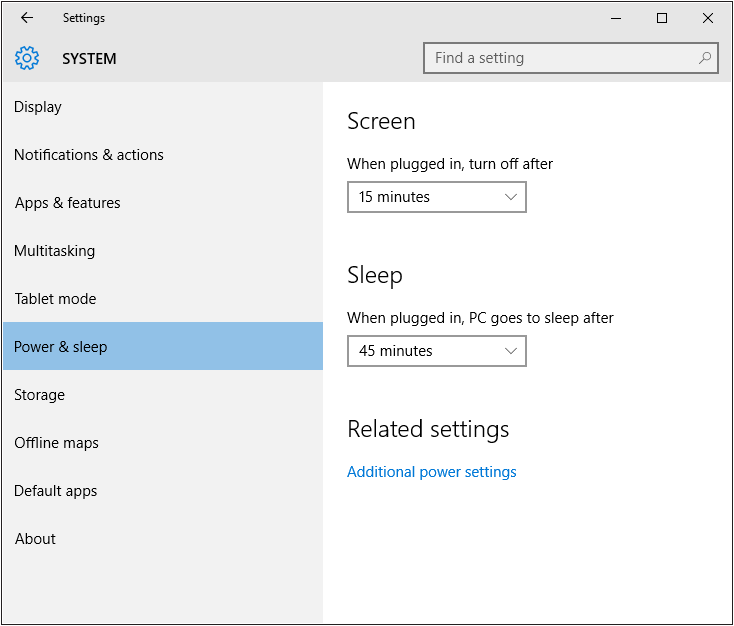


----------------------------------------
[ Source 2 | Type: ImageNode ]
📍 Location: {'page': 34, 'source': 'Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf'}
🖼️ Image Path: /content/drive/MyDrive/data_testing_rag_capstone/capstone_extracted_images/Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf_p34_i1.png
👇 Retrieved Visual Context:


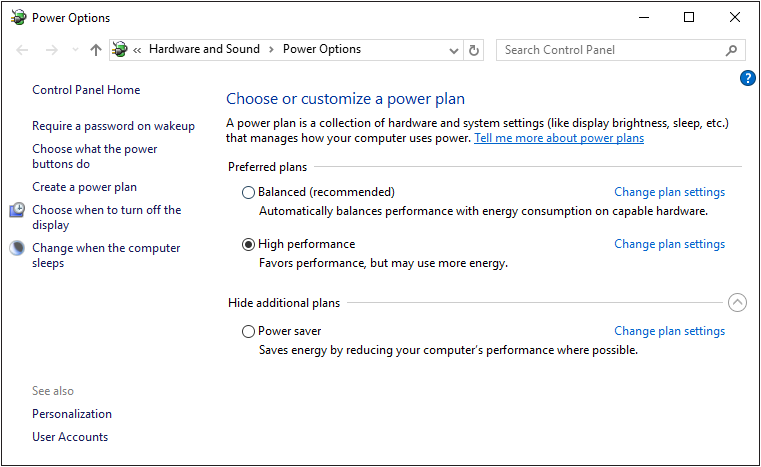

In [ ]:
# Simulate the user's input
user_text_prompt = "Look at the screenshot given. What can be done to power off the computer"
user_uploaded_image = "/content/drive/MyDrive/data_testing_rag_capstone/windows_settings_ui_powernsleep.png"

print("🧠 Processing Query...")

# The "Smart Router"
if user_uploaded_image:
    # 1. IMAGE + TEXT MODE
    print("Detected Image. Running Multimodal Search...")
    response = query_engine.image_query(
        image_path=user_uploaded_image,
        prompt_str=user_text_prompt
    )
else:
    # 2. TEXT ONLY MODE
    print("No image detected. Running Text Search...")
    response = query_engine.query(user_text_prompt)

print(f"\n🤖 SYSTEM RESPONSE:\n{response}")

from IPython.display import display, Image

print("\n🔍 SOURCES USED BY THE SYSTEM:")

for i, node_obj in enumerate(response.source_nodes):
    node = node_obj.node
    metadata = node.metadata
    node_type = type(node).__name__

    print(f"\n{'-'*40}")
    print(f"[ Source {i+1} | Type: {node_type} ]")

    if metadata:
        print(f"📍 Location: {metadata}")

    if node_type == "TextNode":
        content = node.get_content().strip()
        print(f"📄 Text: {content[:300]}...\n")

    elif node_type == "ImageNode":
        img_path = getattr(node, 'image_path', None)

        if img_path and os.path.exists(img_path):
            print(f"🖼️ Image Path: {img_path}")
            print("👇 Retrieved Visual Context:")
            # Display the image inline! Width=500 keeps it from taking up the whole screen.
            display(Image(filename=img_path, width=500))
        else:
            print("🖼️ Image Path: Not found or file missing on disk.\n")

## Transition Into ChatBot

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q -U \
    llama-index-core \
    pymupdf \
    llama-index-embeddings-huggingface \
    llama-index-embeddings-clip \
    llama-index-multi-modal-llms-gemini \
    nest_asyncio \
    git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 7.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
import os
from google.colab import userdata

# LlamaIndex Imports
from llama_index.core import Settings, StorageContext, load_index_from_storage
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.embeddings.clip import ClipEmbedding
from llama_index.multi_modal_llms.gemini import GeminiMultiModal
from llama_index.llms.gemini import Gemini
from llama_index.core.chat_engine import ContextChatEngine

# 1. INITIALIZE YOUR MODELS (Fast)
print("1. Waking up the models...")
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
image_embedder = ClipEmbedding(model_name="ViT-L/14")

os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
# Brain A: The Vision VLM
vision_llm = GeminiMultiModal(model_name="models/gemini-2.5-flash-lite")
# Brain B: The Standard Text LLM (Fixes the MIME bug!)
text_llm = Gemini(model="models/gemini-2.5-flash-lite")

# 2. LOAD THE SAVED INDEX (Instant)
# Make sure this path matches exactly where you saved it!
PERSIST_DIR = "/content/drive/MyDrive/data_testing_rag_capstone/capstone_saved_index"

print("2. Loading the database from Google Drive...")
# Tell the system to look at the folder
storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)

# Load the data into memory
index = load_index_from_storage(
    storage_context,
    image_embed_model=image_embedder # CRITICAL: It needs to know how to read the image vectors!
)

print("3. Connecting the Hybrid Engines...")
Settings.llm = text_llm

# ---------------------------------------------------------
# Engine A: The "Eyes" (Vision Engine)
# We use the built-in multimodal wrapper because it handles images perfectly
# ---------------------------------------------------------
query_engine = index.as_query_engine(
    llm=vision_llm,
    similarity_top_k=3,
    image_similarity_top_k=2
)
# ---------------------------------------------------------
# Engine B: The "Memory" (Chat Engine)
# MANUALLY CONSTRUCTED to bypass the LlamaIndex MIME bug
# ---------------------------------------------------------
# 1. Manually extract a pure-text searcher from the database
text_retriever = index.as_retriever(
    similarity_top_k=3,
    image_similarity_top_k=0 # The absolute shield
)

# 2. Manually build the Chat Engine using our isolated components
chat_engine = ContextChatEngine.from_defaults(
    retriever=text_retriever,
    llm=text_llm
)

print("🚀 DUAL-BRAIN HYBRID SYSTEM ONLINE!")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


1. Waking up the models...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

100%|███████████████████████████████████████| 890M/890M [00:12<00:00, 76.0MiB/s]
/tmp/ipykernel_2854/3439193356.py:19: DeprecationWarning: Call to deprecated class GeminiMultiModal. (This package has been deprecated and will no longer be maintained. Please use llama-index-llms-google-genai instead. See Multi Modal LLMs documentation for a complete guide on migration: https://docs.llamaindex.ai/en/stable/understanding/using_llms/using_llms/#multi-modal-llms.) -- Deprecated since version 0.5.1.
  vision_llm = GeminiMultiModal(model_name="models/gemini-2.5-flash-lite")
/tmp/ipykernel_2854/3439193356.py:21: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  text_llm = Gemini(model="models/gemini-2.5-flash-lite")


2. Loading the database from Google Drive...


3. Connecting the Hybrid Engines...
🚀 DUAL-BRAIN HYBRID SYSTEM ONLINE!


🤖 Windows Manual Assistant is ready! (Type 'exit' to quit)

You: halo
   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: 
🧠 Thinking...
   (Text Only -> Routing to Chat Engine...)

🤖 Gemini: Cortana, a signature feature of Windows 10, is named after a character from the Halo franchise on Xbox. It functions as a personal assistant, capable of understanding spoken commands and converting them into tasks, appointments, or instructions. Cortana can also manage your calendar, track travel itineraries and shipments, provide news, perform calculations, and search the web. While it's not enabled by default, you'll have the option to enable it the first time you click in the search box next to the Start button. If you wish to prevent users in your organization from using Cortana, you can disable it through Group Policy. The setting to allow Cortana can be found under Computer Configuration > Administrative Templates > Windows Components > Search.

---------------------

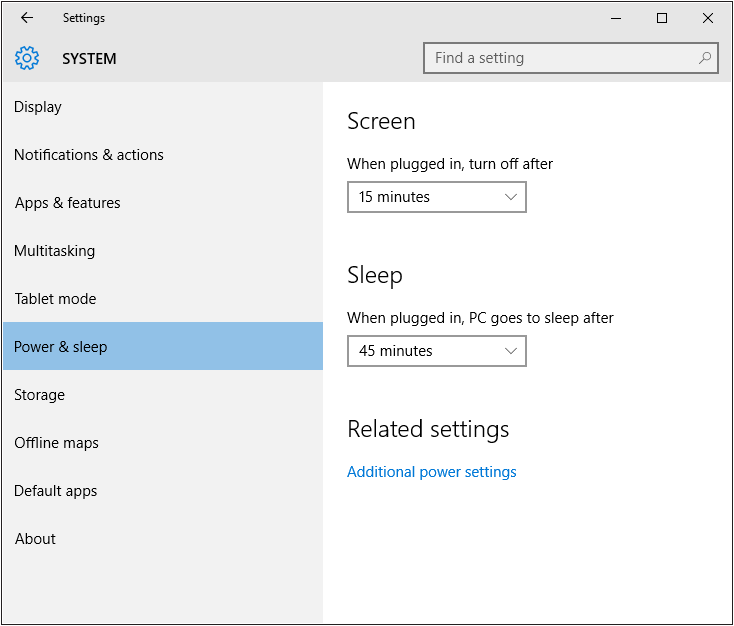


[ Source 2 | Type: ImageNode ]
📍 Location: {'page': 34, 'source': 'Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf'}
🖼️ Displaying context image:


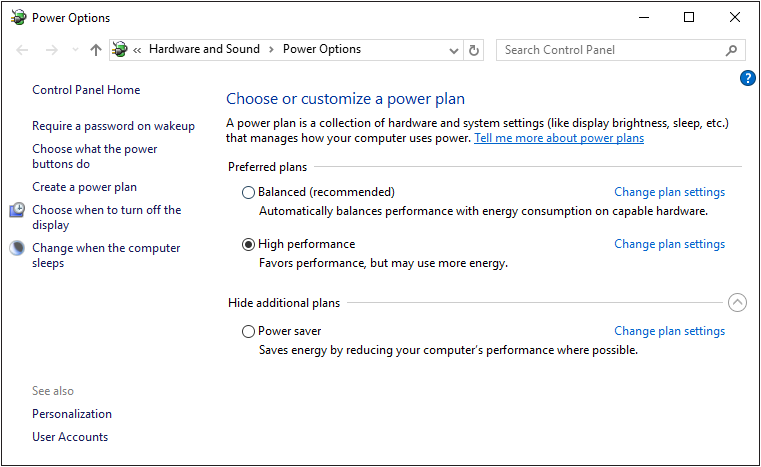

----------------------------------------

You: on the previous image provided, what button should i press to change my maps settings
   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: 
🧠 Thinking...
   (Text Only -> Routing to Chat Engine...)

🤖 Gemini: I cannot provide instructions on how to change your maps settings. The provided context does not contain information on this topic.

----------------------------------------
🔍 SOURCES USED:

[ Source 1 | Type: TextNode ]
📍 Location: {'page': 34, 'source': 'Microsoft_Press_eBook_Introducing_Windows_10_PDF.pdf'}
📄 Text: CHAPTER 2  The Windows 10 user experience	
23
FIGURE 2-4  The number of options in the Settings app is growing steadily, but some tasks still 
offer only a limited selection.
FIGURE 2-5  Less common c...


[ Source 2 | Type: TextNode ]
📍 Location: {'page': 108, 'source': 'windows_manual_userguide.pdf'}
📄 Text: HKEY_CURRENT_USER or HKCU
A Registry Editor can help you make changes to your computer. 

In [ ]:
import os
from IPython.display import display, Image

print("🤖 Windows Manual Assistant is ready! (Type 'exit' to quit)")

while True:
    user_input = input("\nYou: ")

    if user_input.lower() in ['exit', 'quit']:
        print("🤖 Goodbye!")
        break

    image_path = input("   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: ").strip()

    print("🧠 Thinking...")

    try:
        if image_path:
            if not os.path.exists(image_path):
                print(f"⚠️ Error: Could not find an image at '{image_path}'. Check your spelling!")
                continue

            # ➡️ ROUTE TO QUERY ENGINE (Vision)
            print("   (Image Detected -> Routing to Vision Engine...)")
            response = query_engine.image_query(
                image_path=image_path,
                prompt_str=user_input
            )
        else:
            # ➡️ ROUTE TO CHAT ENGINE (Memory)
            print("   (Text Only -> Routing to Chat Engine...)")
            response = chat_engine.chat(user_input)

        # 1. Print the AI's answer
        print(f"\n🤖 Gemini: {response.response}")

        # 2. Print the Capstone-Level Citations!
        print(f"\n{'-'*40}")
        print("🔍 SOURCES USED:")
        for i, node_obj in enumerate(response.source_nodes[:3]):
            node = node_obj.node
            metadata = node.metadata
            node_type = type(node).__name__

            print(f"\n[ Source {i+1} | Type: {node_type} ]")
            if metadata:
                print(f"📍 Location: {metadata}")

            if node_type == "TextNode":
                content = node.get_content().strip()
                print(f"📄 Text: {content[:200]}...\n")

            elif node_type == "ImageNode":
                img_path = getattr(node, 'image_path', None)
                if img_path and os.path.exists(img_path):
                    print(f"🖼️ Displaying context image:")
                    display(Image(filename=img_path, width=400))
                else:
                    print("🖼️ Image Path: Not found on disk.\n")
        print(f"{'-'*40}")

    except Exception as e:
        print(f"⚠️ An error occurred: {e}")

## Finalizing ChatBot

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q -U \
    llama-index-core \
    pymupdf \
    llama-index-embeddings-huggingface \
    llama-index-embeddings-clip \
    llama-index-multi-modal-llms-gemini \
    nest_asyncio \
    git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 9.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


### Embed KB

In [ ]:
import os
import json
from google.colab import drive
from llama_index.core import Document, VectorStoreIndex, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

In [ ]:
print("1. Loading Text Embedder...")
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- PATHS ---
# IMPORTANT: Adjust this path to wherever your JSON file is currently saved!
json_path = "/content/drive/MyDrive/kb_rag_capstone/epson_allinoneprinter_faq_clean.json"
persist_dir = "/content/drive/MyDrive/kb_rag_capstone/json_saved_index"

print("2. Reading JSON Data...")
documents = []

with open(json_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

    # Depending on how your friend saved it, the list of FAQs might be the root,
    # or it might be inside a key like 'data' or 'chunks'.
    chunk_list = raw_data if isinstance(raw_data, list) else raw_data.get('data', raw_data.get('chunks', []))

    for item in chunk_list:
        # Extract the clean text and the metadata
        text_content = item.get('content', '')
        meta = item.get('metadata', {})

        if text_content:
            # Create a LlamaIndex document
            doc = Document(text=text_content, metadata=meta)
            documents.append(doc)

print(f"✅ Successfully loaded {len(documents)} text chunks.")

print("3. Building the Vector Database...")
# Pure text embedding! Super fast.
index = VectorStoreIndex.from_documents(documents, show_progress=True)

print("4. Saving Database to Google Drive...")
os.makedirs(persist_dir, exist_ok=True)
index.storage_context.persist(persist_dir=persist_dir)
print("🚀 JSON INGESTION COMPLETE!")

1. Loading Text Embedder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2. Reading JSON Data...
✅ Successfully loaded 1385 text chunks.
3. Building the Vector Database...


Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/1385 [00:00<?, ?it/s]

4. Saving Database to Google Drive...
🚀 JSON INGESTION COMPLETE!


### The RAG

#### Initiaing the model and loading the data

In [ ]:
import os
import google.generativeai as genai
from PIL import Image
from google.colab import userdata

# LlamaIndex Imports
from llama_index.core import Settings, StorageContext, load_index_from_storage
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.gemini import Gemini
from llama_index.core.chat_engine import ContextChatEngine

print("1. Waking up the Dual-Brain Models...")

# 1a. Global API Key Setup
api_key = userdata.get('GOOGLE_API_KEY')
os.environ["GOOGLE_API_KEY"] = api_key
genai.configure(api_key=api_key)

Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# ---------------------------------------------------------
# Brain 1: The Native Vision Translator
# By using genai directly, we completely bypass LlamaIndex's Pydantic bugs!
# ---------------------------------------------------------
vision_model = genai.GenerativeModel('gemini-2.5-flash')

# ---------------------------------------------------------
# Brain 2: The LlamaIndex RAG Engine
# ---------------------------------------------------------
text_llm = Gemini(model="models/gemini-2.5-flash-lite")
Settings.llm = text_llm

print("2. Loading the JSON database from Google Drive...")
PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/json_saved_index"
storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
index = load_index_from_storage(storage_context)

print("3. Constructing the Pure-Text Chat Engine...")
text_retriever = index.as_retriever(similarity_top_k=3)
chat_engine = ContextChatEngine.from_defaults(
    retriever=text_retriever,
    llm=text_llm
)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


ModuleNotFoundError: No module named 'llama_index'

#### RAG #1

In [ ]:
import os
import json
import base64
import requests
import mimetypes
from google.colab import userdata

# LlamaIndex Imports
from llama_index.core import Settings, StorageContext, load_index_from_storage
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.gemini import Gemini
from llama_index.core.chat_engine import ContextChatEngine

print("1. Waking up the RAG Engine & Custom REST Client...")

# 1a. Global API Key Setup
api_key = userdata.get('GOOGLE_API_KEY')
os.environ["GOOGLE_API_KEY"] = api_key

Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# ---------------------------------------------------------
# Brain 1: The CUSTOM REST VISION TRANSLATOR
# ---------------------------------------------------------
def analyze_image_rest(image_path, text_prompt, key):
    """Bypasses all SDKs and talks directly to Google's servers."""

    # Guess if it's a JPG or PNG
    mime_type, _ = mimetypes.guess_type(image_path)
    if not mime_type:
        mime_type = "image/jpeg"

    # Convert the image to a raw Base64 string
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode('utf-8')

    url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?key={key}"

    # Construct the exact JSON Google expects
    payload = {
        "contents": [{
            "parts": [
                {"text": text_prompt},
                {
                    "inline_data": {
                        "mime_type": mime_type,
                        "data": encoded_string
                    }
                }
            ]
        }]
    }

    # Send it directly over the network
    response = requests.post(url, json=payload)
    response_data = response.json()

    try:
        return response_data['candidates'][0]['content']['parts'][0]['text']
    except KeyError:
        raise Exception(f"Google API Error: {response_data}")

# ---------------------------------------------------------
# Brain 2: The LlamaIndex RAG Engine (Text Only)
# ---------------------------------------------------------
text_llm = Gemini(model="models/gemini-2.5-flash-lite")
Settings.llm = text_llm

print("2. Loading the JSON database from Google Drive...")
PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/json_saved_index"
storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
index = load_index_from_storage(storage_context)

print("3. Constructing the Pure-Text Chat Engine...")
text_retriever = index.as_retriever(similarity_top_k=3)
chat_engine = ContextChatEngine.from_defaults(
    retriever=text_retriever,
    llm=text_llm
)

print("\n🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)\n")

while True:
    user_input = input("\nYou: ")

    if user_input.lower() in ['exit', 'quit']:
        print("🤖 Goodbye!")
        break

    image_path = input("   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: ").strip()

    print("🧠 Thinking...")

    try:
        final_search_query = user_input

        # --- THE VISION TRANSLATOR (CUSTOM REST API) ---
        if image_path:
            if not os.path.exists(image_path):
                print(f"⚠️ Error: Could not find image at '{image_path}'.")
                continue

            print("   (👁️ Reading User Image natively via REST...)")

            vision_prompt = f"The user asked: '{user_input}'. Look at this image of a printer/screen. Extract any error codes, warning text, or describe the visual issue specifically so I can search a text troubleshooting database."

            # Call our custom network function!
            image_description = analyze_image_rest(image_path, vision_prompt, api_key)

            print(f"   (📝 Vision Translation: {image_description[:80]}...)")

            final_search_query = f"User Request: {user_input}\nImage Context: {image_description}"

        # --- THE TEXT RAG SEARCH (LLAMAINDEX) ---
        print("   (📚 Searching Knowledge Base...)")
        response = chat_engine.chat(final_search_query)

        print(f"\n🤖 Gemini: {response.response}")

        # --- CITATION PRINTER ---
        print(f"\n{'-'*50}")
        print("🔍 SOURCES USED:")
        for i, node_obj in enumerate(response.source_nodes[:3]):
            node = node_obj.node
            metadata = node.metadata

            product = metadata.get('product_name', 'Unknown Product')
            faq_id = metadata.get('faq_id', 'Unknown ID')

            print(f"\n[ Source {i+1} | Model: {product} | FAQ ID: {faq_id} ]")
            print(f"📄 Data: {node.get_content().strip()[:200]}...\n")
        print(f"{'-'*50}\n")

    except Exception as e:
        print(f"⚠️ An error occurred: {e}")

1. Waking up the RAG Engine & Custom REST Client...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_12899/1975940322.py:66: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  text_llm = Gemini(model="models/gemini-2.5-flash-lite")


2. Loading the JSON database from Google Drive...
3. Constructing the Pure-Text Chat Engine...

🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)


You: what part of the printer should i open to see the machine inside
   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: /content/epson_printer.jpg
🧠 Thinking...
   (👁️ Reading User Image natively via REST...)
   (📝 Vision Translation: Based on the image provided:

*   **Error Codes / Warning Text:** There are no e...)
   (📚 Searching Knowledge Base...)

🤖 Gemini: Based on the provided context, to access parts of the printer for maintenance or troubleshooting, you might need to open the following:

*   **Ink tank cover:** This is mentioned in the context of transporting or storing the Epson ET-3850.
*   **Scanner unit:** This is also mentioned in the context of transporting or storing the Epson ET-3850. The instructions state to "Lower the scanner unit using both hands."
*   **Output tray:** This is m

#### RAG #2 - With the RAG giving signal for ticket

In [ ]:
import os
import json
import base64
import requests
import mimetypes
from google.colab import userdata

# LlamaIndex Imports
from llama_index.core import Settings, StorageContext, load_index_from_storage
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.gemini import Gemini
from llama_index.core.chat_engine import ContextChatEngine

print("1. Waking up the RAG Engine & Custom REST Client...")

# 1a. Global API Key Setup
api_key = userdata.get('GOOGLE_API_KEY')
os.environ["GOOGLE_API_KEY"] = api_key

Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# ---------------------------------------------------------
# Brain 1: The CUSTOM REST VISION TRANSLATOR
# ---------------------------------------------------------
def analyze_image_rest(image_path, text_prompt, key):
    """Bypasses all SDKs and talks directly to Google's servers."""

    # Guess if it's a JPG or PNG
    mime_type, _ = mimetypes.guess_type(image_path)
    if not mime_type:
        mime_type = "image/jpeg"

    # Convert the image to a raw Base64 string
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode('utf-8')

    url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?key={key}"

    # Construct the exact JSON Google expects
    payload = {
        "contents": [{
            "parts": [
                {"text": text_prompt},
                {
                    "inline_data": {
                        "mime_type": mime_type,
                        "data": encoded_string
                    }
                }
            ]
        }]
    }

    # Send it directly over the network
    response = requests.post(url, json=payload)
    response_data = response.json()

    try:
        return response_data['candidates'][0]['content']['parts'][0]['text']
    except KeyError:
        raise Exception(f"Google API Error: {response_data}")

# ---------------------------------------------------------
# Brain 2: The LlamaIndex RAG Engine (Text Only)
# ---------------------------------------------------------
text_llm = Gemini(model="models/gemini-2.5-flash-lite")
Settings.llm = text_llm

print("2. Loading the JSON database from Google Drive...")
PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/json_saved_index"
storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
index = load_index_from_storage(storage_context)


print("3. Constructing the Pure-Text Chat Engine...")
text_retriever = index.as_retriever(similarity_top_k=3)

# --- NEW: THE TICKET ROUTING PROMPT ---
custom_system_prompt = (
    "You are an Epson Printer Technical Support Assistant. "
    "You must answer the user's question using ONLY the provided database context. "
    "If the provided context does not contain the answer, DO NOT guess, DO NOT hallucinate, and DO NOT use outside knowledge. "
    "If you cannot answer the question using the context, you must reply with EXACTLY this string: CREATE_SUPPORT_TICKET_FLAG"
)

# Inject the prompt into the engine
chat_engine = ContextChatEngine.from_defaults(
    retriever=text_retriever,
    llm=text_llm,
    system_prompt=custom_system_prompt
)

print("\n🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)\n")

while True:
    user_input = input("\nYou: ")

    if user_input.lower() in ['exit', 'quit']:
        print("🤖 Goodbye!")
        break

    image_path = input("   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: ").strip()

    print("🧠 Thinking...")

    try:
        final_search_query = user_input

        # --- THE VISION TRANSLATOR (CUSTOM REST API) ---
        if image_path:
            if not os.path.exists(image_path):
                print(f"⚠️ Error: Could not find image at '{image_path}'.")
                continue

            print("   (👁️ Reading User Image natively via REST...)")

            vision_prompt = f"The user asked: '{user_input}'. Look at this image of a printer/screen. Extract any error codes, warning text, or describe the visual issue specifically so I can search a text troubleshooting database."

            # Call our custom network function!
            image_description = analyze_image_rest(image_path, vision_prompt, api_key)

            print(f"   (📝 Vision Translation: {image_description[:80]}...)")

            final_search_query = f"User Request: {user_input}\nImage Context: {image_description}"

        # --- THE TEXT RAG SEARCH (LLAMAINDEX) ---
        print("   (📚 Searching Knowledge Base...)")
        response = chat_engine.chat(final_search_query)

        # Clean up the text response
        ai_answer = response.response.strip()

        # --- THE BACKEND INTERCEPTOR ---
        if "CREATE_SUPPORT_TICKET_FLAG" in ai_answer:
            # THIS IS WHAT HAPPENS IF NO ANSWER IS FOUND
            print("\n🤖 Gemini: I couldn't find the exact solution for that in our manual.")

            # --- For your backend team: ---
            # return {"status": "unresolved", "ticket_required": True, "user_query": user_input}
            print("   🚨 [BACKEND SIGNAL: Triggering Ticket Creation UI...]")

        else:
            # THIS IS WHAT HAPPENS IF IT FINDS THE ANSWER
            print(f"\n🤖 Gemini: {ai_answer}")

            # --- CITATION PRINTER ---
            print(f"\n{'-'*50}")
            print("🔍 SOURCES USED:")
            for i, node_obj in enumerate(response.source_nodes[:3]):
                node = node_obj.node
                metadata = node.metadata
                product = metadata.get('product_name', 'Unknown Product')
                faq_id = metadata.get('faq_id', 'Unknown ID')
                print(f"\n[ Source {i+1} | Model: {product} | FAQ ID: {faq_id} ]")
                print(f"📄 Data: {node.get_content().strip()[:200]}...\n")
            print(f"{'-'*50}\n")

    except Exception as e:
        print(f"⚠️ An error occurred: {e}")

1. Waking up the RAG Engine & Custom REST Client...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_12899/3170263158.py:66: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  text_llm = Gemini(model="models/gemini-2.5-flash-lite")


2. Loading the JSON database from Google Drive...
3. Constructing the Pure-Text Chat Engine...

🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)


You: what to do if the ink went solid
   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: 
🧠 Thinking...
   (📚 Searching Knowledge Base...)


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 13193.86ms



🤖 Gemini: If ink gets on your skin, wash it thoroughly with soap and water. If ink gets into your eyes, flush them immediately with water. If ink gets into your mouth, spit it out immediately. Seek medical advice if problems persist. Keep the ink bottles out of the reach of children and do not drink the ink.

To refill the ink tanks:
1. Position the top of the ink bottle along the slot in front of the filling port, then slowly stand the bottle up to insert it. Do not force the bottles into position; they are keyed for each color.
2. Wait for the ink to fill the tank. Do not squeeze the bottle. Ink flows into the tank and stops automatically when the ink is filled to the upper line. If ink does not flow, lift and reinsert the bottle.
3. When the ink tank is full, remove the ink bottle and securely close the ink tank cap. If any ink remains in the bottle, replace the bottle cap and tighten it. Store the bottle upright for later use.
4. Repeat the previous steps as necessary for each ink

### Metrics Evaluation

#### \#1 Evaluation

In [ ]:
import json
import random
from llama_index.core import StorageContext, load_index_from_storage, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

print("1. Waking up the HuggingFace Embedding Model...")
# WE MUST DECLARE THIS BEFORE LOADING THE INDEX!
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

print("2. Loading the saved database...")
# Make sure your paths match!
PERSIST_DIR = "/content/drive/MyDrive/data_testing_rag_capstone/json_saved_index"
JSON_PATH = "/content/drive/MyDrive/kb_rag_capstone/epson_allinoneprinter_faq_clean.json"

storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
# Now when it loads, it knows exactly how to read your vectors!
index = load_index_from_storage(storage_context)

# Extract JUST the retriever (we don't need the LLM to generate answers for this test)
K_VALUE = 3
retriever = index.as_retriever(similarity_top_k=K_VALUE)

print("3. Building the Evaluation Dataset...")
# We will extract questions and their true 'faq_id' from your JSON
test_dataset = []

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    chunk_list = raw_data if isinstance(raw_data, list) else raw_data.get('data', raw_data.get('chunks', []))

    for item in chunk_list:
        meta = item.get('metadata', {})
        question = meta.get('question', '')
        faq_id = meta.get('faq_id', '')

        # Only use items that actually have a question and an ID
        if question and faq_id:
            test_dataset.append({"question": question, "true_id": faq_id})

# Randomly select 30 questions to evaluate (so it doesn't take hours)
random.seed(42) # Seed ensures the same random questions are picked every time
eval_subset = random.sample(test_dataset, min(30, len(test_dataset)))

print(f"✅ Created test dataset of {len(eval_subset)} questions.\n")

print(f"4. Running Retriever Evaluation (Top-{K_VALUE})...")
total_hits = 0
total_precision = 0.0

for i, test_case in enumerate(eval_subset):
    query = test_case["question"]
    expected_id = test_case["true_id"]

    # Run the search!
    retrieved_nodes = retriever.retrieve(query)

    # Extract the faq_ids from the documents the AI found
    retrieved_ids = [node.node.metadata.get('faq_id') for node in retrieved_nodes]

    # -- CALCULATE METRICS FOR THIS QUERY --
    is_hit = expected_id in retrieved_ids

    if is_hit:
        total_hits += 1
        # Precision: How many relevant docs did we get / Total docs retrieved
        # (Since there is only 1 true doc in our dataset per question, it's 1 / K)
        total_precision += (1.0 / K_VALUE)

    # Just print the first 5 so you can see it working
    if i < 5:
        print(f"Q: {query[:50]}...")
        print(f"   Expected: {expected_id} | Retrieved: {retrieved_ids} | Hit? {'✅' if is_hit else '❌'}")

# -- CALCULATE FINAL SCORES --
final_hit_rate = (total_hits / len(eval_subset)) * 100
final_precision = (total_precision / len(eval_subset)) * 100

print(f"\n{'-'*40}")
print("🏆 CAPSTONE EVALUATION RESULTS")
print(f"{'-'*40}")
print(f"Total Test Questions: {len(eval_subset)}")
print(f"Documents Retrieved per Question (k): {K_VALUE}")
print(f"🎯 Hit Rate:      {final_hit_rate:.2f}%")
print(f"📏 Precision@{K_VALUE}: {final_precision:.2f}%")
print(f"{'-'*40}")

1. Waking up the HuggingFace Embedding Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2. Loading the saved database...
3. Building the Evaluation Dataset...
✅ Created test dataset of 30 questions.

4. Running Retriever Evaluation (Top-3)...
Q: I can't print from Windows with a wireless connect...
   Expected: faq-00009cc-et5800_5850 | Retrieved: ['faq-00009cc-et4700', 'faq-00009cc-et3950_series', 'faq-00009cc-et3760'] | Hit? ❌
Q: How do I print a borderless photo from Windows or ...
   Expected: faq-00004ff-et1910_et1913 | Retrieved: ['faq-00004ff-et2720', 'faq-00004ff-et15000_l14150', 'faq-00004ff-et2760'] | Hit? ❌
Q: It takes a long time to copy a document. What shou...
   Expected: faq-0000511-et15000_l14150 | Retrieved: ['faq-0000511-et3750', 'faq-0000511-et2760', 'faq-0000511-et4750'] | Hit? ❌
Q: I can't print from my Mac with a wireless connecti...
   Expected: faq-00009cb-et2760 | Retrieved: ['faq-00009CB-et16500', 'faq-00009cb-et5800_5850', 'faq-00009cb-et4760'] | Hit? ❌
Q: How do I know when an ink tank needs to be refille...
   Expected: faq-00007eb-et2750 | R

#### \#2 Mitigation & Evalution

In [ ]:
import os
import json
from llama_index.core import Document, VectorStoreIndex, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

print("1. Waking up the HuggingFace Embedder...")
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- PATHS ---
json_path = "/content/drive/MyDrive/kb_rag_capstone/epson_allinoneprinter_faq_clean.json"
# NEW FOLDER to save our injected experiment
persist_dir = "/content/drive/MyDrive/kb_rag_capstone/minilm_injected_index"

print("2. Reading JSON Data & INJECTING METADATA...")
documents = []

with open(json_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    chunk_list = raw_data if isinstance(raw_data, list) else raw_data.get('data', raw_data.get('chunks', []))

    for item in chunk_list:
        text_content = item.get('content', '')
        meta = item.get('metadata', {})

        if text_content:
            # --- THE METADATA INJECTION MAGIC ---
            product = meta.get('product_name', 'Unknown Epson Printer')
            question = meta.get('question', 'Unknown Question')

            # We stitch the metadata directly into the top of the text string!
            injected_text = f"PRINTER MODEL: {product}\nQUESTION: {question}\n\nANSWER: {text_content}"

            # Pass the enhanced text to LlamaIndex
            doc = Document(text=injected_text, metadata=meta)
            documents.append(doc)

print(f"✅ Successfully injected and loaded {len(documents)} chunks.")

print("3. Building the Vector Database...")
index = VectorStoreIndex.from_documents(documents, show_progress=True)

print("4. Saving Database to Google Drive...")
os.makedirs(persist_dir, exist_ok=True)
index.storage_context.persist(persist_dir=persist_dir)
print("🚀 METADATA INJECTION COMPLETE!")

1. Waking up the HuggingFace Embedder...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2. Reading JSON Data & INJECTING METADATA...
✅ Successfully injected and loaded 1385 chunks.
3. Building the Vector Database...


Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/1385 [00:00<?, ?it/s]

4. Saving Database to Google Drive...
🚀 METADATA INJECTION COMPLETE!


In [ ]:
import json
import random
from llama_index.core import StorageContext, load_index_from_storage, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

print("1. Waking up the HuggingFace Embedding Model...")
# WE MUST DECLARE THIS BEFORE LOADING THE INDEX!
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

print("2. Loading the saved database...")
# Make sure your paths match!
PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/minilm_injected_index"
JSON_PATH = "/content/drive/MyDrive/kb_rag_capstone/epson_allinoneprinter_faq_clean.json"

storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
# Now when it loads, it knows exactly how to read your vectors!
index = load_index_from_storage(storage_context)

# Extract JUST the retriever (we don't need the LLM to generate answers for this test)
K_VALUE = 3
retriever = index.as_retriever(similarity_top_k=K_VALUE)

print("3. Building the Evaluation Dataset...")
# We will extract questions and their true 'faq_id' from your JSON
test_dataset = []

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    chunk_list = raw_data if isinstance(raw_data, list) else raw_data.get('data', raw_data.get('chunks', []))

    for item in chunk_list:
        meta = item.get('metadata', {})
        question = meta.get('question', '')
        faq_id = meta.get('faq_id', '')

        # Only use items that actually have a question and an ID
        if question and faq_id:
            test_dataset.append({"question": question, "true_id": faq_id})

# Randomly select 30 questions to evaluate (so it doesn't take hours)
random.seed(42) # Seed ensures the same random questions are picked every time
eval_subset = random.sample(test_dataset, min(30, len(test_dataset)))

print(f"✅ Created test dataset of {len(eval_subset)} questions.\n")

print(f"4. Running Retriever Evaluation (Top-{K_VALUE})...")
total_hits = 0
total_precision = 0.0

for i, test_case in enumerate(eval_subset):
    query = test_case["question"]
    expected_id = test_case["true_id"]

    # Run the search!
    retrieved_nodes = retriever.retrieve(query)

    # Extract the faq_ids from the documents the AI found
    retrieved_ids = [node.node.metadata.get('faq_id') for node in retrieved_nodes]

    # -- CALCULATE METRICS FOR THIS QUERY --
    is_hit = expected_id in retrieved_ids

    if is_hit:
        total_hits += 1
        # Precision: How many relevant docs did we get / Total docs retrieved
        # (Since there is only 1 true doc in our dataset per question, it's 1 / K)
        total_precision += (1.0 / K_VALUE)

    # Just print the first 5 so you can see it working
    if i < 5:
        print(f"Q: {query[:50]}...")
        print(f"   Expected: {expected_id} | Retrieved: {retrieved_ids} | Hit? {'✅' if is_hit else '❌'}")

# -- CALCULATE FINAL SCORES --
final_hit_rate = (total_hits / len(eval_subset)) * 100
final_precision = (total_precision / len(eval_subset)) * 100

print(f"\n{'-'*40}")
print("🏆 CAPSTONE EVALUATION RESULTS")
print(f"{'-'*40}")
print(f"Total Test Questions: {len(eval_subset)}")
print(f"Documents Retrieved per Question (k): {K_VALUE}")
print(f"🎯 Hit Rate:      {final_hit_rate:.2f}%")
print(f"📏 Precision@{K_VALUE}: {final_precision:.2f}%")
print(f"{'-'*40}")

1. Waking up the HuggingFace Embedding Model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2. Loading the saved database...
3. Building the Evaluation Dataset...
✅ Created test dataset of 30 questions.

4. Running Retriever Evaluation (Top-3)...
Q: I can't print from Windows with a wireless connect...
   Expected: faq-00009cc-et5800_5850 | Retrieved: ['faq-00009cc-et4950_4958', 'faq-00009cc-et2760', 'faq-00009cc-et4760'] | Hit? ❌
Q: How do I print a borderless photo from Windows or ...
   Expected: faq-00004ff-et1910_et1913 | Retrieved: ['faq-00004ff-et15000_l14150', 'faq-00004ff-et2760', 'faq-00004ff-et4760'] | Hit? ❌
Q: It takes a long time to copy a document. What shou...
   Expected: faq-0000511-et15000_l14150 | Retrieved: ['faq-0000511-et2720', 'faq-0000511-et4700', 'faq-0000511-et2400'] | Hit? ❌
Q: I can't print from my Mac with a wireless connecti...
   Expected: faq-00009cb-et2760 | Retrieved: ['faq-00009cb-et5800_5850', 'faq-00009cb-et4760', 'faq-00009cb-et2760'] | Hit? ✅
Q: How do I know when an ink tank needs to be refille...
   Expected: faq-00007eb-et2750 | Retr

#### \#3 Mitigation & Evaluation

In [ ]:
!pip install -q llama-index-retrievers-bm25 rank_bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.3/683.3 kB 16.5 MB/s eta 0:00:00


Using dummy LLM

In [ ]:
import json
import random
import os
from google.colab import userdata

from llama_index.core import StorageContext, load_index_from_storage, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# --- NEW HYBRID IMPORTS ---
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.core.llms import MockLLM # <--- THE NEW MAGIC SHIELD

print("1. Waking up our Models (Offline Mode!)...")

# 1. Force the Embedder to HuggingFace (Runs locally)
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# 2. Force the LLM to a Dummy Brain!
# This stops LlamaIndex from calling OpenAI OR Gemini, preventing ALL network crashes.
Settings.llm = MockLLM()

print("2. Loading the Injected Database...")
PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/minilm_injected_index"
JSON_PATH = "/content/drive/MyDrive/kb_rag_capstone/epson_allinoneprinter_faq_clean.json"

storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
index = load_index_from_storage(storage_context)

K_VALUE = 3

print("3. Building the Hybrid Fusion Retriever...")
# A. The Vector Engine (Understands meaning)
vector_retriever = index.as_retriever(similarity_top_k=K_VALUE)

# B. The Keyword Engine (Understands exact words/numbers)
nodes = list(index.docstore.docs.values())
bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=K_VALUE)

# C. The Fusion Engine (Combines both scores!)
hybrid_retriever = QueryFusionRetriever(
    [vector_retriever, bm25_retriever],
    similarity_top_k=K_VALUE,
    num_queries=1,
    mode="reciprocal_rerank"
)

# ... (The rest of your Evaluation Loop goes here) ...

print("4. Building the Evaluation Dataset...")
test_dataset = []

with open(JSON_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    chunk_list = raw_data if isinstance(raw_data, list) else raw_data.get('data', raw_data.get('chunks', []))

    for item in chunk_list:
        meta = item.get('metadata', {})
        question = meta.get('question', '')
        faq_id = meta.get('faq_id', '')

        # Only use items that actually have a question and an ID
        if question and faq_id:
            # We add the product name to the question to simulate a real user asking about their specific printer
            product = meta.get('product_name', '')
            simulated_query = f"{product} - {question}"
            test_dataset.append({"question": simulated_query, "true_id": faq_id})

# Randomly select 30 questions
random.seed(42)
eval_subset = random.sample(test_dataset, min(30, len(test_dataset)))

print(f"✅ Created test dataset of {len(eval_subset)} questions.\n")

print(f"5. Running Hybrid Evaluation (Top-{K_VALUE})...")
total_hits = 0
total_precision = 0.0

for i, test_case in enumerate(eval_subset):
    query = test_case["question"]
    expected_id = test_case["true_id"]

    # --- WE CALL THE HYBRID RETRIEVER HERE ---
    retrieved_nodes = hybrid_retriever.retrieve(query)

    retrieved_ids = [node.node.metadata.get('faq_id') for node in retrieved_nodes]

    is_hit = expected_id in retrieved_ids

    if is_hit:
        total_hits += 1
        total_precision += (1.0 / K_VALUE)

    if i < 5:
        print(f"Q: {query[:60]}...")
        print(f"   Expected: {expected_id} | Retrieved: {retrieved_ids} | Hit? {'✅' if is_hit else '❌'}")

# -- CALCULATE FINAL SCORES --
final_hit_rate = (total_hits / len(eval_subset)) * 100
final_precision = (total_precision / len(eval_subset)) * 100

print(f"\n{'-'*40}")
print("🏆 HYBRID CAPSTONE EVALUATION RESULTS")
print(f"{'-'*40}")
print(f"🎯 Hit Rate:      {final_hit_rate:.2f}%")
print(f"📏 Precision@{K_VALUE}: {final_precision:.2f}%")
print(f"{'-'*40}")

1. Waking up our Models (Offline Mode!)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2. Loading the Injected Database...
3. Building the Hybrid Fusion Retriever...


DEBUG:bm25s:Building index from IDs objects


4. Building the Evaluation Dataset...
✅ Created test dataset of 30 questions.

5. Running Hybrid Evaluation (Top-3)...
Q: Epson ET-5850 - I can't print from Windows with a wireless c...
   Expected: faq-00009cc-et5800_5850 | Retrieved: ['faq-00009cc-et5800_5850', 'faq-00009cc-et4760', 'faq-00009cb-et5800_5850'] | Hit? ✅
Q: Epson ET-1913 - How do I print a borderless photo from Windo...
   Expected: faq-00004ff-et1910_et1913 | Retrieved: ['faq-00004ff-et1910_et1913', 'faq-00004ff-et1910_et1913', 'faq-00004ff-et15000_l14150'] | Hit? ✅
Q: Epson ET-15000 - It takes a long time to copy a document. Wh...
   Expected: faq-0000511-et15000_l14150 | Retrieved: ['faq-0000511-et15000_l14150', 'faq-0000511-et2400', 'faq-0000511-et16500'] | Hit? ✅
Q: Epson ET-2760 - I can't print from my Mac with a wireless co...
   Expected: faq-00009cb-et2760 | Retrieved: ['faq-00009cb-et2760', 'faq-00009cb-et4760', 'faq-00009CB-et16500'] | Hit? ✅
Q: Epson ET-2750 - How do I know when an ink tank needs to be r...


#### Were getting a really good results. Now, lets try with using real LLM

In [ ]:
!pip install -q llama-index-llms-huggingface-api \
                llama-index-retrievers-bm25 \
                rank_bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.3/683.3 kB 12.9 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import userdata

from llama_index.core import Settings, StorageContext, load_index_from_storage
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.gemini import Gemini
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.core.chat_engine import ContextChatEngine

print("Waking up the Dual-Brain LLM Architecture...")

os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# --- THE EMBEDDER ---
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- THE LLMS ---
primary_llm = Gemini(model="models/gemini-2.5-flash-lite")
backup_llm = HuggingFaceInferenceAPI(
    model_name="Qwen/Qwen2.5-7B-Instruct",
    token=os.environ["HF_TOKEN"]
)

Settings.llm = primary_llm

print("Loading the Injected Database...")
PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/minilm_injected_index"
JSON_PATH = "/content/drive/MyDrive/kb_rag_capstone/epson_allinoneprinter_faq_clean.json"

storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
index = load_index_from_storage(storage_context)

K_VALUE = 3

print("Building the Hybrid Fusion Retriever...")
# A. The Vector Engine (Understands meaning)
vector_retriever = index.as_retriever(similarity_top_k=K_VALUE)

# B. The Keyword Engine (Understands exact words/numbers)
nodes = list(index.docstore.docs.values())
bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=K_VALUE)

# C. The Fusion Engine (Combines both scores!)
hybrid_retriever = QueryFusionRetriever(
    [vector_retriever, bm25_retriever],
    similarity_top_k=K_VALUE,
    num_queries=1,
    mode="reciprocal_rerank"
)

# --- THE DUAL ENGINES ---
print("Building the Primary and Backup Chat Engines...")

# --- THE ANTI-LAZY ROUTING PROMPT ---
custom_system_prompt = (
    "You are an Epson Printer Technical Support Assistant. "
    "You must answer the user's question using ONLY the provided database context. "
    "If the provided context does not contain the answer, DO NOT guess, DO NOT hallucinate, and DO NOT use outside knowledge. "
    "If you cannot answer the question using the context, you must reply with EXACTLY this string: CREATE_SUPPORT_TICKET_FLAG\n\n"

    "STRICT INSTRUCTIONS FOR FORMATTING YOUR ANSWER:\n"
    "1. If the answer contains a process, troubleshooting guide, or set of instructions, you MUST list EVERY single step explicitly in your response using a numbered list.\n"
    "2. DO NOT give lazy answers like 'follow the on-screen instructions', 'refer to the manual', or 'check the website'. You must extract the actual steps from the context and write them out fully.\n"
    "3. ALWAYS respond in the exact same language the user used to ask the question (e.g., if they ask in Indonesian, reply in Indonesian)."
)

primary_engine = ContextChatEngine.from_defaults(
    retriever=hybrid_retriever,
    llm=primary_llm,
    system_prompt=custom_system_prompt
)

backup_engine = ContextChatEngine.from_defaults(
    retriever=hybrid_retriever,
    llm=backup_llm,
    system_prompt=custom_system_prompt
)

print("✅ Primary: Gemini 2.5 | Backup: HuggingFace Zephyr\n")

print("\n🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)\n")

while True:
    user_input = input("\nYou: ")

    if user_input.lower() in ['exit', 'quit']:
        print("🤖 Goodbye!")
        break

    image_path = input("   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: ").strip()

    print("🧠 Thinking...")

    try:
        final_search_query = user_input

        # --- THE VISION TRANSLATOR (CUSTOM REST API) ---
        if image_path:
            if not os.path.exists(image_path):
                print(f"⚠️ Error: Could not find image at '{image_path}'.")
                continue

            print("   (👁️ Reading User Image natively via REST...)")

            vision_prompt = f"The user asked: '{user_input}'. Look at this image of a printer/screen. Extract any error codes, warning text, or describe the visual issue specifically so I can search a text troubleshooting database."

            # Call our custom network function!
            image_description = analyze_image_rest(image_path, vision_prompt, api_key)

            print(f"   (📝 Vision Translation: {image_description[:80]}...)")

            final_search_query = f"User Request: {user_input}\nImage Context: {image_description}"

        # --- THE TEXT RAG SEARCH & GENERATION ---
        print("   (📚 Searching Knowledge Base & Generating Answer...)")

        try:
            # 1. PRIMARY ROUTE (Google Gemini)
            response = primary_engine.chat(final_search_query)
            print(f"\n🤖 Gemini: {response.response}")

        except Exception as primary_error:
            # 2. FAILOVER ROUTE (HuggingFace Qwen)
            # This triggers automatically if Google's API crashes or limits you
            print(f"\n⚠️ Gemini API Error: {primary_error}")
            print("🔄 Seamlessly rerouting request to Qwen Backup Engine...")

            try:
                response = backup_engine.chat(final_search_query)
                print(f"\n🤖 Qwen (Backup): {response.response}")
            except Exception as backup_error:
                # 3. ABSOLUTE WORST CASE SCENARIO
                print(f"\n🚨 CRITICAL: Both AI APIs are down. Please check your internet connection. Error: {backup_error}")
                continue # Skip the citation printer and wait for the next question

        # --- CITATION PRINTER ---
        print(f"\n{'-'*50}")
        print("🔍 SOURCES USED:")
        for i, node_obj in enumerate(response.source_nodes[:3]):
            node = node_obj.node
            metadata = node.metadata
            product = metadata.get('product_name', 'Unknown Product')
            faq_id = metadata.get('faq_id', 'Unknown ID')
            print(f"\n[ Source {i+1} | Model: {product} | FAQ ID: {faq_id} ]")
            print(f"📄 Data: {node.get_content().strip()[:200]}...\n")
        print(f"{'-'*50}\n")

    except Exception as e:
        print(f"⚠️ An error occurred: {e}")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Waking up the Dual-Brain LLM Architecture...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_1780/1403114214.py:21: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  primary_llm = Gemini(model="models/gemini-2.5-flash-lite")


Loading the Injected Database...
Building the Hybrid Fusion Retriever...


DEBUG:bm25s:Building index from IDs objects


Building the Primary and Backup Chat Engines...
✅ Primary: Gemini 2.5 | Backup: HuggingFace Zephyr


🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)


You: bagaimana cara untuk melakukan instalasi software?
   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: 
🧠 Thinking...
   (📚 Searching Knowledge Base & Generating Answer...)

🤖 Gemini: The following options are available:
You can use Epson Software Updater (which is installed the first time you install the printer driver) to notify you when new updates are available for download. Software Updater analyzes the Epson software (drivers, utilities, firmware, etc.) installed on your computer and product, and notifies you if new updates are available for download.
If you already installed a Windows printer driver, you can update the driver by selecting
Software Update
on the Maintenance tab in the printer driver settings window.
You can download the software from the Downloads tab on your product's 

### Updating and Managing KB

#### Embed latest KB

With the updated KB that have link in its content

In [ ]:
import os
import json
from llama_index.core import Document, VectorStoreIndex, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

print("1. Waking up the HuggingFace Embedder...")
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- PATHS ---
json_path = "/content/drive/MyDrive/kb_rag_capstone/epson_printer_faq_clean.json"
# NEW FOLDER to save our injected experiment
persist_dir = "/content/drive/MyDrive/kb_rag_capstone/minilm_injected_index"

print("2. Reading JSON Data & INJECTING METADATA...")
documents = []

with open(json_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    chunk_list = raw_data if isinstance(raw_data, list) else raw_data.get('data', raw_data.get('chunks', []))

    for item in chunk_list:
        text_content = item.get('content', '')
        meta = item.get('metadata', {})

        if text_content:
            # --- THE METADATA INJECTION MAGIC ---
            product = meta.get('product_name', 'Epson Printer')
            question = meta.get('question', 'Unknown Question')

            # We stitch the metadata directly into the top of the text string!
            injected_text = f"PRINTER MODEL: {product}\nQUESTION: {question}\n\nANSWER: {text_content}"

            # Pass the enhanced text to LlamaIndex
            faq_identity = meta.get('faq_id')
            doc = Document(text=injected_text, metadata=meta, id_=faq_identity)
            documents.append(doc)

print(f"✅ Successfully injected and loaded {len(documents)} chunks.")

print("3. Building the Vector Database...")
index = VectorStoreIndex.from_documents(documents, show_progress=True)

print("4. Saving Database to Google Drive...")
os.makedirs(persist_dir, exist_ok=True)
index.storage_context.persist(persist_dir=persist_dir)
print("🚀 METADATA INJECTION COMPLETE!")

1. Waking up the HuggingFace Embedder...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2. Reading JSON Data & INJECTING METADATA...
✅ Successfully injected and loaded 108 chunks.
3. Building the Vector Database...


Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/115 [00:00<?, ?it/s]

4. Saving Database to Google Drive...
🚀 METADATA INJECTION COMPLETE!


#### Building the RAG system

In [ ]:
!pip install -q llama-index-llms-huggingface-api \
                llama-index-retrievers-bm25 \
                rank_bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 683.3/683.3 kB 18.8 MB/s eta 0:00:00


Building the RAG-Chatbot system

In [ ]:
import os
from google.colab import userdata

from llama_index.core import Settings, StorageContext, load_index_from_storage
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.llms.gemini import Gemini
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.core.chat_engine import ContextChatEngine

print("Waking up the Dual-Brain LLM Architecture...")

os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# --- THE EMBEDDER ---
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- THE LLMS ---
primary_llm = Gemini(model="models/gemini-2.5-flash-lite")
backup_llm = HuggingFaceInferenceAPI(
    model_name="Qwen/Qwen2.5-7B-Instruct",
    token=os.environ["HF_TOKEN"]
)

Settings.llm = primary_llm

print("Loading the Injected Database...")
PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/minilm_injected_index"

storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
index = load_index_from_storage(storage_context)

K_VALUE = 3

print("Building the Hybrid Fusion Retriever...")
# A. The Vector Engine (Understands meaning)
vector_retriever = index.as_retriever(similarity_top_k=K_VALUE)

# B. The Keyword Engine (Understands exact words/numbers)
nodes = list(index.docstore.docs.values())
bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=K_VALUE)

# C. The Fusion Engine (Combines both scores!)
hybrid_retriever = QueryFusionRetriever(
    [vector_retriever, bm25_retriever],
    similarity_top_k=K_VALUE,
    num_queries=1,
    mode="reciprocal_rerank"
)

# --- THE DUAL ENGINES ---
print("Building the Primary and Backup Chat Engines...")

# --- THE ANTI-LAZY ROUTING PROMPT ---
custom_system_prompt = (
    "You are an Epson Printer Technical Support Assistant. "
    "You must answer the user's question using ONLY the provided database context. "
    "If the provided context does not contain the answer, DO NOT guess, DO NOT hallucinate, and DO NOT use outside knowledge. "
    "If you cannot answer the question using the context, you must reply with EXACTLY this string: CREATE_SUPPORT_TICKET_FLAG\n\n"

    "STRICT INSTRUCTIONS FOR FORMATTING YOUR ANSWER:\n"
    "1. If the answer contains a process, troubleshooting guide, or set of instructions, you MUST list EVERY single step explicitly in your response using a numbered list.\n"
    "2. DO NOT give lazy answers like 'follow the on-screen instructions', 'refer to the manual', or 'check the website'. You must extract the actual steps from the context and write them out fully.\n"
    "3. ALWAYS respond in the exact same language the user used to ask the question (e.g., if they ask in Indonesian, reply in Indonesian)."
)

primary_engine = ContextChatEngine.from_defaults(
    retriever=hybrid_retriever,
    llm=primary_llm,
    system_prompt=custom_system_prompt
)

backup_engine = ContextChatEngine.from_defaults(
    retriever=hybrid_retriever,
    llm=backup_llm,
    system_prompt=custom_system_prompt
)

print("✅ Primary: Gemini 2.5 | Backup: HuggingFace Zephyr\n")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Waking up the Dual-Brain LLM Architecture...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_2203/3348918144.py:21: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  primary_llm = Gemini(model="models/gemini-2.5-flash-lite")


Loading the Injected Database...


DEBUG:bm25s:Building index from IDs objects


Building the Hybrid Fusion Retriever...
Building the Primary and Backup Chat Engines...
✅ Primary: Gemini 2.5 | Backup: HuggingFace Zephyr



Testing

In [ ]:
print("\n🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)\n")

while True:
    user_input = input("\nYou: ")

    if user_input.lower() in ['exit', 'quit']:
        print("🤖 Goodbye!")
        break

    image_path = input("   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: ").strip()

    print("🧠 Thinking...")

    try:
        final_search_query = user_input

        # --- THE VISION TRANSLATOR (CUSTOM REST API) ---
        if image_path:
            if not os.path.exists(image_path):
                print(f"⚠️ Error: Could not find image at '{image_path}'.")
                continue

            print("   (👁️ Reading User Image natively via REST...)")

            vision_prompt = f"The user asked: '{user_input}'. Look at this image of a printer/screen. Extract any error codes, warning text, or describe the visual issue specifically so I can search a text troubleshooting database."

            # Call our custom network function!
            image_description = analyze_image_rest(image_path, vision_prompt, api_key)

            print(f"   (📝 Vision Translation: {image_description[:80]}...)")

            final_search_query = f"User Request: {user_input}\nImage Context: {image_description}"

        # --- THE TEXT RAG SEARCH & GENERATION ---
        print("   (📚 Searching Knowledge Base & Generating Answer...)")

        try:
            # 1. PRIMARY ROUTE (Google Gemini)
            response = primary_engine.chat(final_search_query)
            print(f"\n🤖 Gemini: {response.response}")

        except Exception as primary_error:
            # 2. FAILOVER ROUTE (HuggingFace Qwen)
            # This triggers automatically if Google's API crashes or limits you
            print(f"\n⚠️ Gemini API Error: {primary_error}")
            print("🔄 Seamlessly rerouting request to Qwen Backup Engine...")

            try:
                response = backup_engine.chat(final_search_query)
                print(f"\n🤖 Qwen (Backup): {response.response}")
            except Exception as backup_error:
                # 3. ABSOLUTE WORST CASE SCENARIO
                print(f"\n🚨 CRITICAL: Both AI APIs are down. Please check your internet connection. Error: {backup_error}")
                continue # Skip the citation printer and wait for the next question

        # --- CITATION PRINTER ---
        print(f"\n{'-'*50}")
        print("🔍 SOURCES USED:")
        for i, node_obj in enumerate(response.source_nodes[:3]):
            node = node_obj.node
            metadata = node.metadata
            product = metadata.get('product_name', 'Unknown Product')
            faq_id = metadata.get('faq_id', 'Unknown ID')
            print(f"\n[ Source {i+1} | Model: {product} | FAQ ID: {faq_id} ]")
            print(f"📄 Data: {node.get_content().strip()[:200]}...\n")
        print(f"{'-'*50}\n")

    except Exception as e:
        print(f"⚠️ An error occurred: {e}")


🚀 BARE-METAL MULTIMODAL ASSISTANT ONLINE! (Type 'exit' to quit)


You: what to do when the printer ink leaked
   📸 (Optional) Paste image path & press Enter, or just press Enter to skip: 
🧠 Thinking...
   (📚 Searching Knowledge Base & Generating Answer...)

🤖 Gemini: If ink spills, wipe it up immediately. To prevent the ink from spreading, blot the spill with a dry cloth, then quickly wipe it with a damp cloth. The ink will be hard to remove once it has dried. If the ink does not come off, try scrubbing it with the appropriate cleaning product where the ink spilled.

--------------------------------------------------
🔍 SOURCES USED:

[ Source 1 | Model: Epson EcoTank ET-2400 | FAQ ID: FAQ_AF7C77CA ]
📄 Data: PRINTER MODEL: Epson EcoTank ET-2400
QUESTION: Are there any safety precautions I should take when handling the ink?

ANSWER: Question: Are there any safety precautions I should take when handling the...


[ Source 2 | Model: Epson EcoTank ET-2400 | FAQ ID: FAQ_1223B444 ]
📄 Data: P

#### Managing KB

In [ ]:
import os
import uuid
from llama_index.core import StorageContext, load_index_from_storage, Document
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core import Settings

# 1. Initialize the Embedder (Required for LlamaIndex to load properly)
Settings.embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

PERSIST_DIR = "/content/drive/MyDrive/kb_rag_capstone/minilm_injected_index"

def load_live_database():
    """Loads the database from storage."""
    print("Loading Vector Database...")
    storage_context = StorageContext.from_defaults(persist_dir=PERSIST_DIR)
    return load_index_from_storage(storage_context)

def admin_list_categories(index):
    """Scans the Document Store and extracts all unique categories."""
    unique_categories = set()

    # We access the internal document dictionary directly!
    for doc_id, node in index.docstore.docs.items():
        category = node.metadata.get('category', 'Unknown')
        unique_categories.add(category)

    print("\n📁 AVAILABLE CATEGORIES:")
    for cat in sorted(unique_categories):
        print(f" - {cat}")

def admin_view_questions_by_category(index, target_category):
    """Displays all questions and their specific IDs for a chosen category."""
    print(f"\n📄 QUESTIONS IN CATEGORY: '{target_category}'")
    print("-" * 50)

    found = False
    for doc_id, node in index.docstore.docs.items():
        if node.metadata.get('category') == target_category:
            faq_id = node.metadata.get('faq_id')
            question = node.metadata.get('question')
            print(f"[ID: {faq_id}] Q: {question}")
            found = True

    if not found:
        print("No questions found in this category.")
    print("-" * 50)

def admin_delete_faq(index, target_faq_id):
    """Deletes a specific FAQ from the live database."""
    try:
        # LlamaIndex searches for the ID and destroys the vector mathematically
        index.delete_ref_doc(target_faq_id, delete_from_docstore=True)
        # MUST persist to save the deletion permanently!
        index.storage_context.persist(persist_dir=PERSIST_DIR)
        print(f"✅ Successfully deleted FAQ ID: {target_faq_id}")
    except Exception as e:
        print(f"❌ Failed to delete. Error: {e}")

def admin_update_faq(index, target_faq_id, new_answer_text):
    """Updates an existing FAQ with new answer text."""
    # 1. Find the old node to grab its existing metadata (so we don't lose the category/URL)
    old_node = None
    for doc_id, node in index.docstore.docs.items():
        if node.metadata.get('faq_id') == target_faq_id:
            old_node = node
            break

    if not old_node:
        print(f"❌ Could not find FAQ ID: {target_faq_id}")
        return

    # 2. Extract old metadata and prep the new text
    meta = old_node.metadata
    product = meta.get('product_name', 'Epson ET-2400')
    question = meta.get('question', '')

    # We maintain the injection structure
    new_injected_text = f"PRINTER MODEL: {product}\nQuestion: {question}\nAnswer Context:\n{new_answer_text}"

    # 3. Create the replacement document using the EXACT SAME ID
    updated_doc = Document(text=new_injected_text, metadata=meta, id_=target_faq_id)

    # 4. Overwrite in the index and save
    index.update_ref_doc(updated_doc)
    index.storage_context.persist(persist_dir=PERSIST_DIR)
    print(f"✅ Successfully updated FAQ ID: {target_faq_id}")

def admin_add_new_faq(index, question, answer_text, category, source_url="Manual Admin Entry"):
    """Inserts a brand new FAQ into the live Vector Database."""
    # 1. Generate a new, unique ID matching our schema format
    new_faq_id = f"FAQ_{uuid.uuid4().hex[:8].upper()}"
    product = "Epson EcoTank ET-2400"

    # 2. Build the metadata dictionary EXACTLY as the scraper does
    meta = {
        "faq_id": new_faq_id,
        "product_name": product,
        "question": question,
        "category": category,
        "source_url": source_url
    }

    # 3. Inject the text perfectly so the Vector Embedder understands it
    injected_text = f"PRINTER MODEL: {product}\nQuestion: {question}\nAnswer Context:\n{answer_text}"

    # 4. Bind the text, metadata, and ID into a LlamaIndex Document
    new_doc = Document(text=injected_text, metadata=meta, id_=new_faq_id)

    # 5. Insert into the index and permanently save to the drive
    try:
        index.insert(new_doc)
        index.storage_context.persist(persist_dir=PERSIST_DIR)
        print(f"✅ Successfully added NEW FAQ! [ID: {new_faq_id}] in Category: '{category}'")
        return new_faq_id
    except Exception as e:
        print(f"❌ Failed to add new FAQ. Error: {e}")
        return None

def admin_view_single_faq(index, target_faq_id):
    """Retrieves and displays the full question and answer text for a specific FAQ ID."""
    print(f"\n🔍 LOOKING UP FAQ ID: {target_faq_id}")
    print("-" * 50)

    # 1. Search the document store for the exact ID
    target_node = None
    for doc_id, node in index.docstore.docs.items():
        if node.metadata.get('faq_id') == target_faq_id:
            target_node = node
            break

    # 2. Handle the case where the ID is wrong or deleted
    if not target_node:
        print(f"❌ Could not find FAQ ID: {target_faq_id} in the database.")
        print("-" * 50)
        return

    # 3. Extract the metadata and text
    meta = target_node.metadata
    category = meta.get('category', 'Unknown Category')
    source_url = meta.get('source_url', 'No URL')

    # .get_content() pulls the exact string the AI reads (including our injected PRINTER MODEL tags)
    full_text = target_node.get_content()

    # 4. Print it cleanly for the Admin
    print(f"📂 Category: {category}")
    print(f"🔗 Source URL: {source_url}\n")
    print(f"📝 EXACT DATABASE CONTENT:")
    print(full_text)
    print("-" * 50)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


##### Test - Adding QnA

In [ ]:
# ==========================================
# 🚀 ADMIN CONSOLE EXECUTION
# ==========================================
if __name__ == "__main__":
    db_index = load_live_database()

    print('Before: ')
    # Verify it shows up in the category list immediately!
    admin_view_questions_by_category(db_index, "Software or Setup")

    print("\n--- TEST: ADDING A NEW FAQ ---")
    new_question = "How do I print a test page directly from the printer buttons?"
    new_answer = "Step 1: Turn off the printer.\nStep 2: Hold down the power button and the cancel button simultaneously for 5 seconds."
    new_category = "Software or Setup"

    # Execute the addition
    admin_add_new_faq(db_index, new_question, new_answer, new_category)

    print("\nAfter: ")
    # Verify it shows up in the category list immediately!
    admin_view_questions_by_category(db_index, "Software or Setup")

Loading Vector Database...
Before: 

📄 QUESTIONS IN CATEGORY: 'Software or Setup'
--------------------------------------------------
[ID: FAQ_6F17153F] Q: How do I add my product as an IP printer on my Mac?
[ID: FAQ_7FAC19A3] Q: How do I change the font size of text when I print from software in Windows?
[ID: FAQ_149C0076] Q: Where can I find the IP address of my router?
[ID: FAQ_2E66852F] Q: Who do I contact for software support?
[ID: FAQ_07BC960A] Q: Does Epson make drivers for Linux?
[ID: FAQ_0DB717C6] Q: How do I obtain the latest product software for Windows or my Mac?
[ID: FAQ_9157DF17] Q: What are the port numbers for Epson network printers (wired and wireless)?
[ID: FAQ_02F8BEF4] Q: How do I turn off the pop-up messages from Epson Event Manager in Windows 10?
[ID: FAQ_45878AE9] Q: I can't get Epson Status Monitor to work over my wireless network. What should I do?
[ID: FAQ_DE2B34E5] Q: How do I uninstall the Epson printer and scanning software in Windows or on my Mac?
[ID: FAQ_

##### Test - Modifying QnA

In [ ]:
# ==========================================
# 🚀 ADMIN CONSOLE EXECUTION
# ==========================================

db_index = load_live_database()

# Example Workflow:
# 1. Admin checks what categories exist
admin_list_categories(db_index)

# 2. Admin wants to edit something about Ink, so they view the Ink category
admin_view_questions_by_category(db_index, "Software or Setup")

# 3. Admin copies the ID from the terminal and runs the update
# (Uncomment and replace with a real ID to test!)
test_id = "FAQ_F8500D5F"
new_text = "Step 1: Turn off the printer.\nStep 2: Hold down the power button and the cancel button simultaneously for 5 seconds.\n\nNote: Make sure the paper be taken out completely before grabbing the paper."
admin_update_faq(db_index, test_id, new_text)

Loading Vector Database...

📁 AVAILABLE CATEGORIES:
 - Cloud or Mobile
 - Copy or Print
 - Error Messages or Lights
 - Ink
 - Maintenance
 - Other
 - Paper or Media
 - Print Quality or Appearance
 - Scan
 - Software or Setup
 - Wireless or Wired Connection

📄 QUESTIONS IN CATEGORY: 'Software or Setup'
--------------------------------------------------
[ID: FAQ_6F17153F] Q: How do I add my product as an IP printer on my Mac?
[ID: FAQ_7FAC19A3] Q: How do I change the font size of text when I print from software in Windows?
[ID: FAQ_149C0076] Q: Where can I find the IP address of my router?
[ID: FAQ_2E66852F] Q: Who do I contact for software support?
[ID: FAQ_07BC960A] Q: Does Epson make drivers for Linux?
[ID: FAQ_0DB717C6] Q: How do I obtain the latest product software for Windows or my Mac?
[ID: FAQ_9157DF17] Q: What are the port numbers for Epson network printers (wired and wireless)?
[ID: FAQ_02F8BEF4] Q: How do I turn off the pop-up messages from Epson Event Manager in Windows 10?
[

In [ ]:
# Admin checking on the updated question
admin_view_single_faq(db_index, test_id)


🔍 LOOKING UP FAQ ID: FAQ_F8500D5F
--------------------------------------------------
📂 Category: Software or Setup
🔗 Source URL: Manual Admin Entry

📝 EXACT DATABASE CONTENT:
PRINTER MODEL: Epson EcoTank ET-2400
Question: How do I print a test page directly from the printer buttons?
Answer Context:
Step 1: Turn off the printer.
Step 2: Hold down the power button and the cancel button simultaneously for 5 seconds.

Note: Make sure the paper be taken out completely before grabbing the paper.
--------------------------------------------------
